ARTI308 - Machine Learning
# Seaborn Overview

Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.




## Distribution Plots

Let's discuss some plots that allow us to visualize the distribution of a data set. These plots are:

* distplot
* jointplot
* pairplot
* rugplot
* kdeplot

## Imports

In [ ]:
#the inital imports
import seaborn as sns 
import matplotlib.pyplot as plt
plt.ion()
%matplotlib inline    

## Data
Seaborn comes with built-in data sets!

In [ ]:
tips = sns.load_dataset('tips') #loading the default seaborn dataset 

In [ ]:
tips.head() #showing the head of the tips dataset that is provided with seaborn

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## distplot

The distplot shows the distribution of a univariate set of observations.

C:\Users\almok\AppData\Local\Temp\ipykernel_21544\2100106727.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tips['total_bill'])


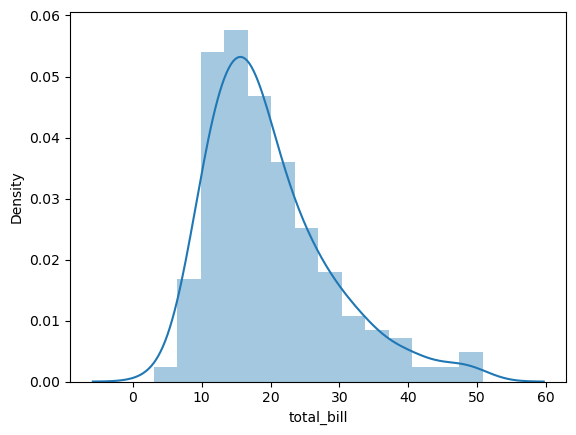

In [ ]:
sns.distplot(tips['total_bill']) #plotting the total bill
plt.show()
# Safe to ignore warnings

To remove the kde layer and just have the histogram use:

C:\Users\almok\AppData\Local\Temp\ipykernel_21544\3448543489.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tips['total_bill'],kde=False,bins=30)


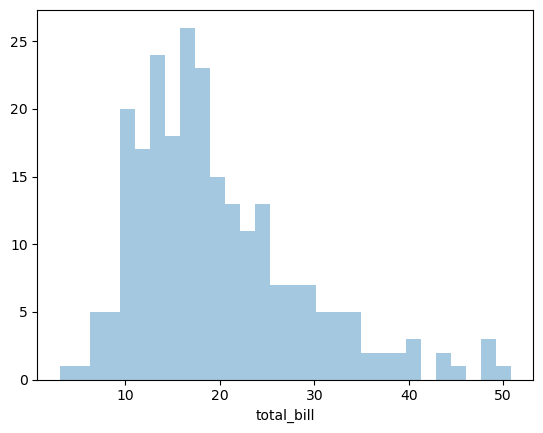

In [ ]:
sns.distplot(tips['total_bill'],kde=False,bins=30)
plt.show()
#plotting the total bill and removing the KDE layer 

## jointplot

jointplot() allows you to basically match up two distplots for bivariate data. With your choice of what **kind** parameter to compare with: 
* “scatter” 
* “reg” 
* “resid” 
* “kde” 
* “hex”

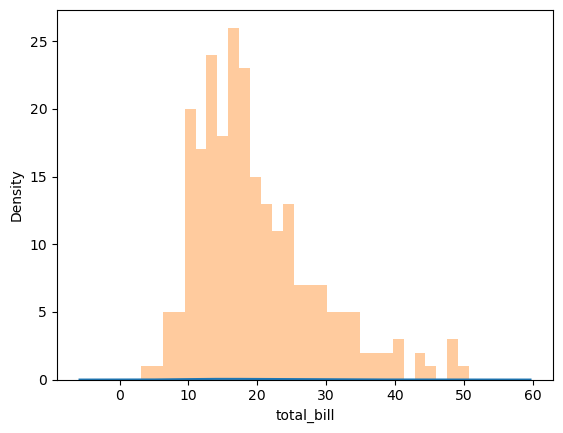

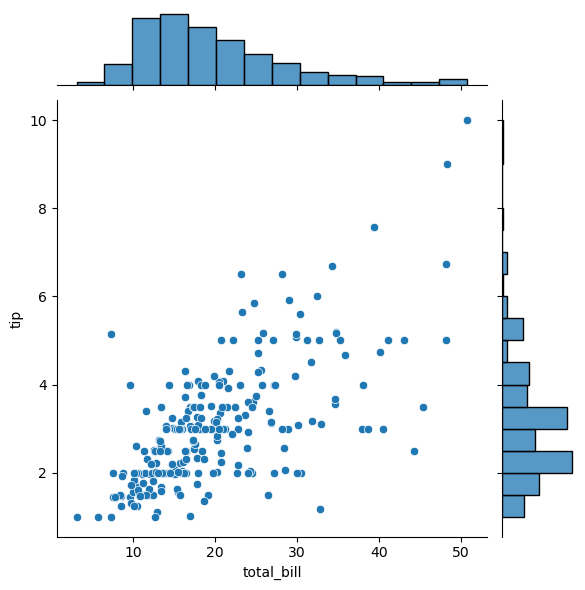

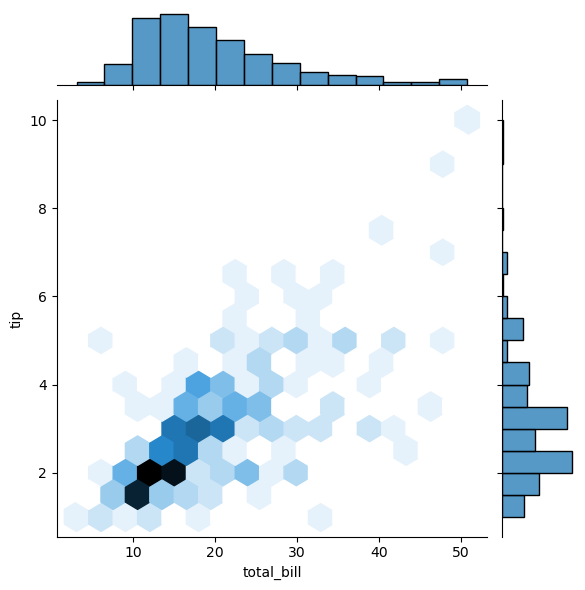

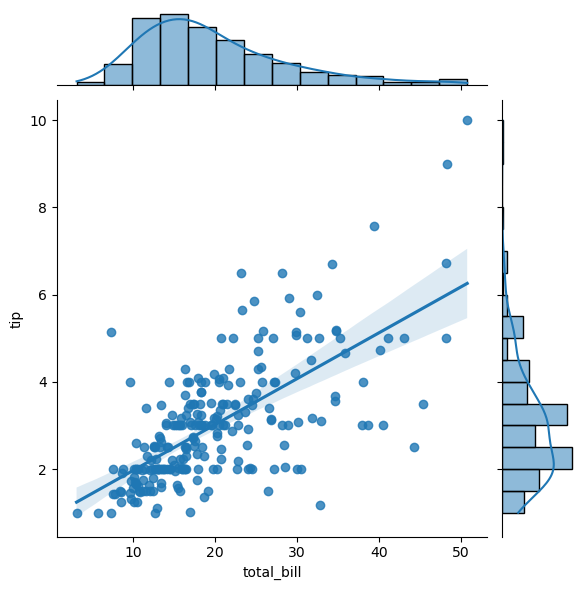

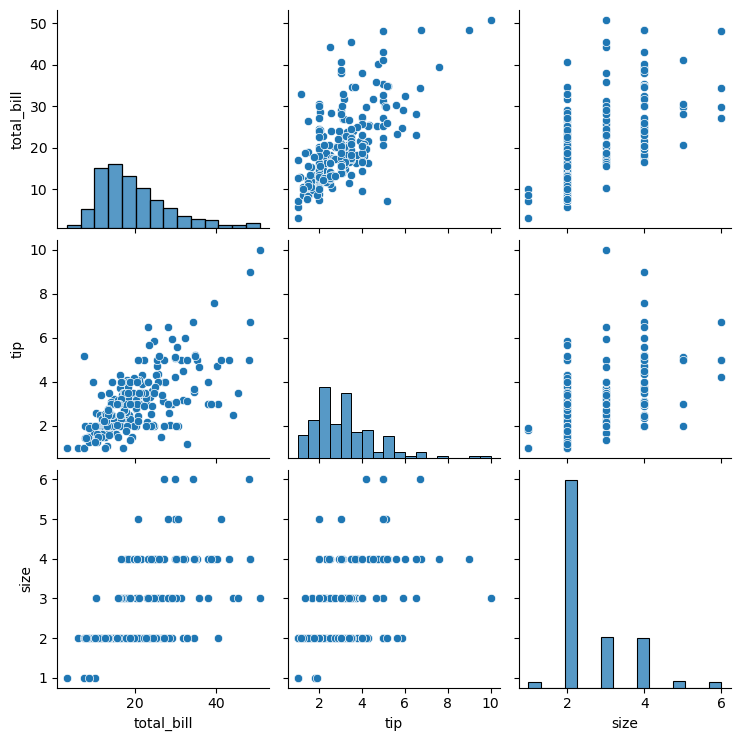

c:\Users\almok\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


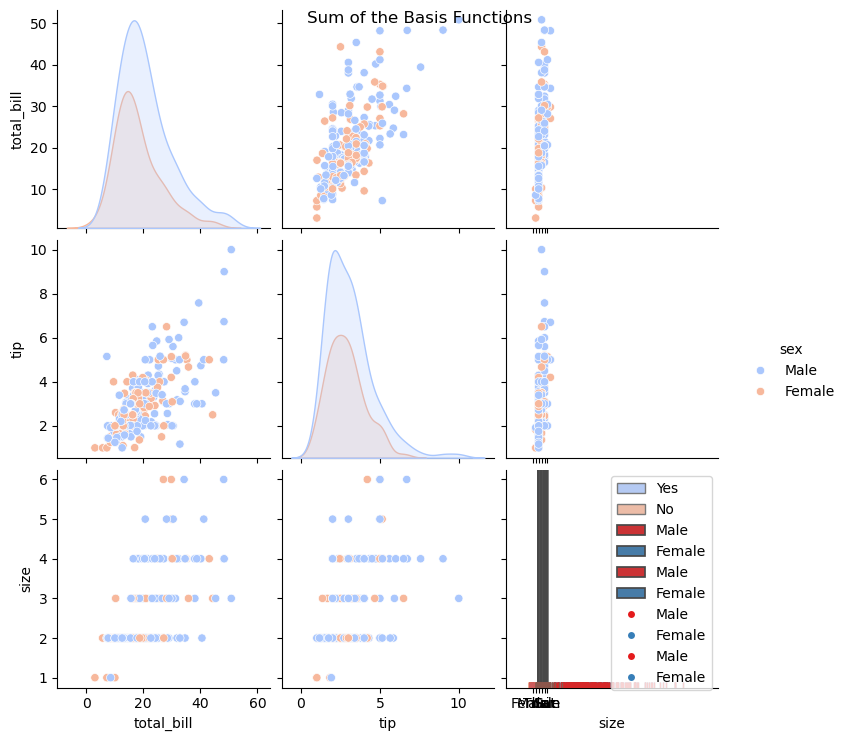

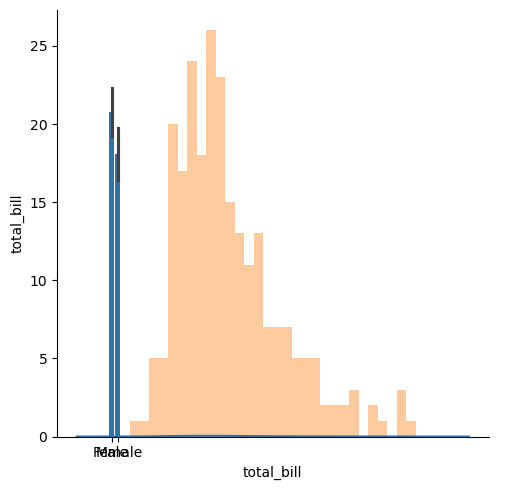

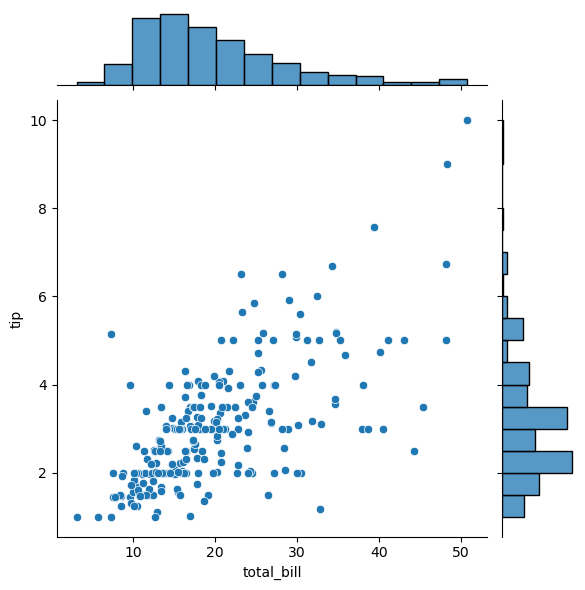

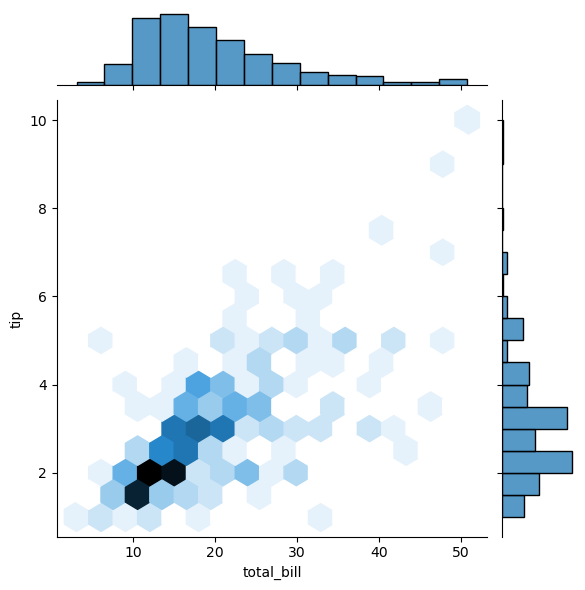

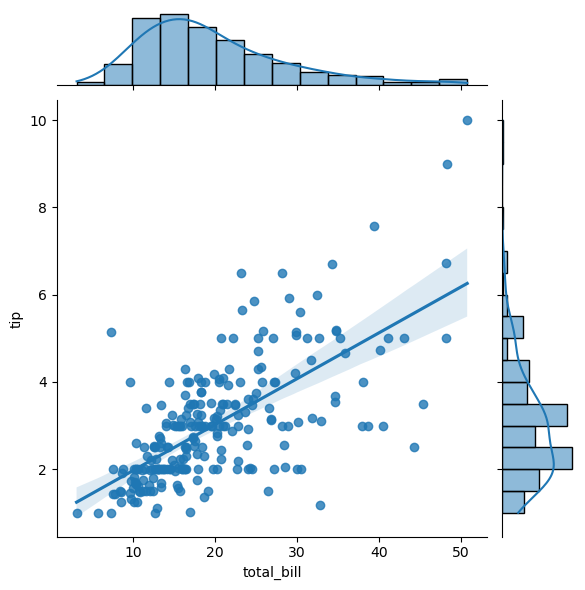

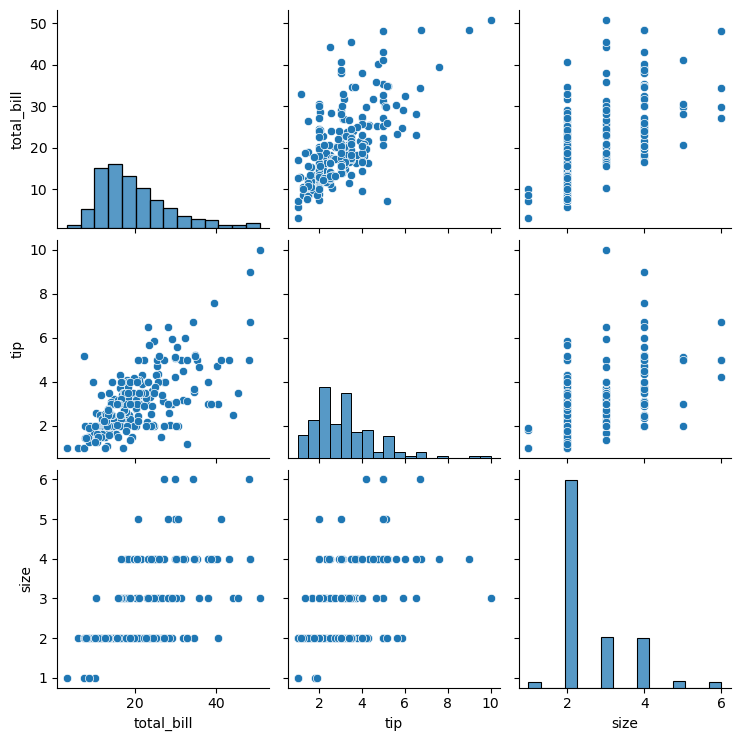

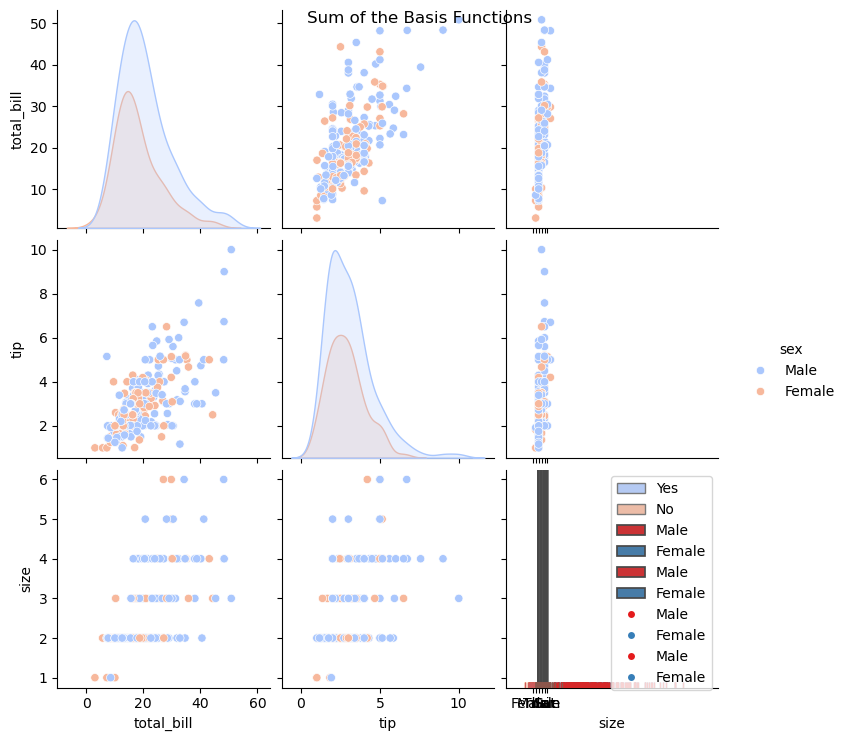

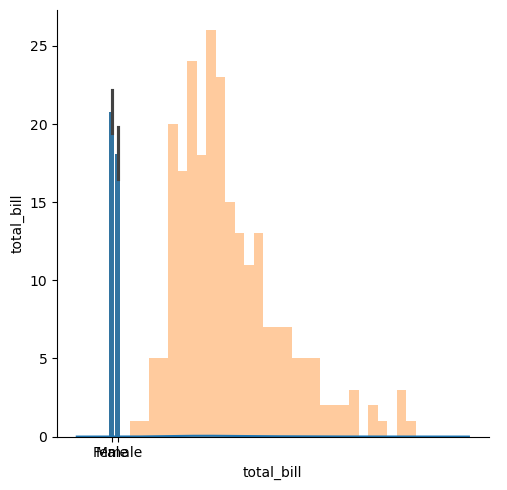

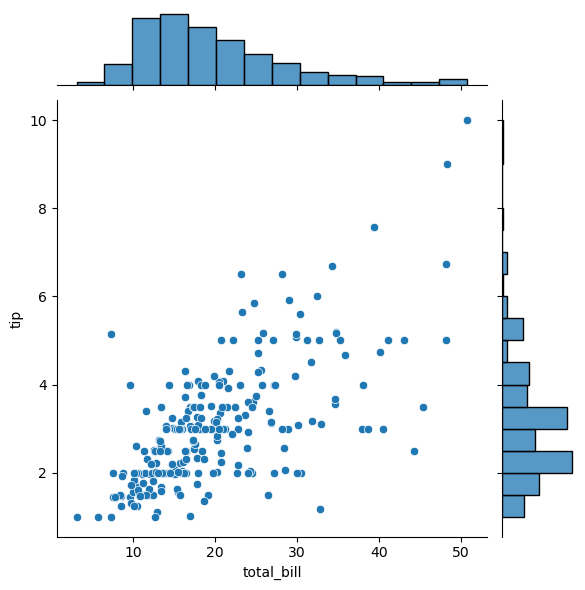

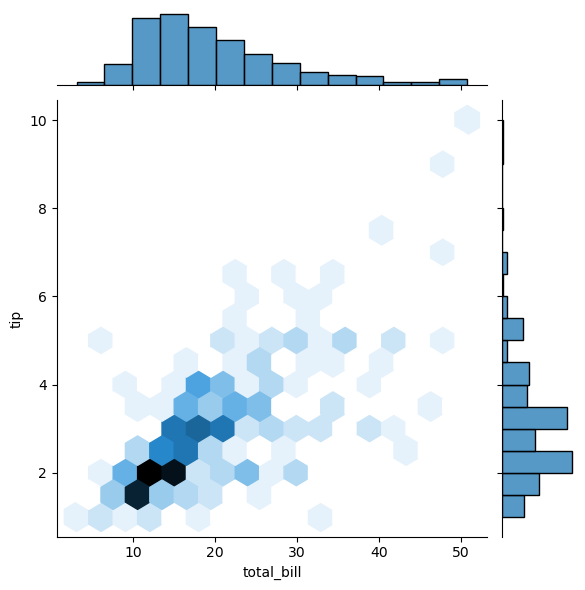

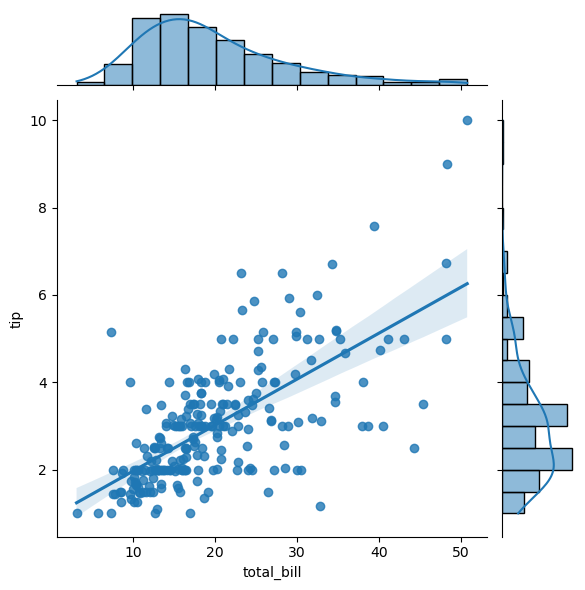

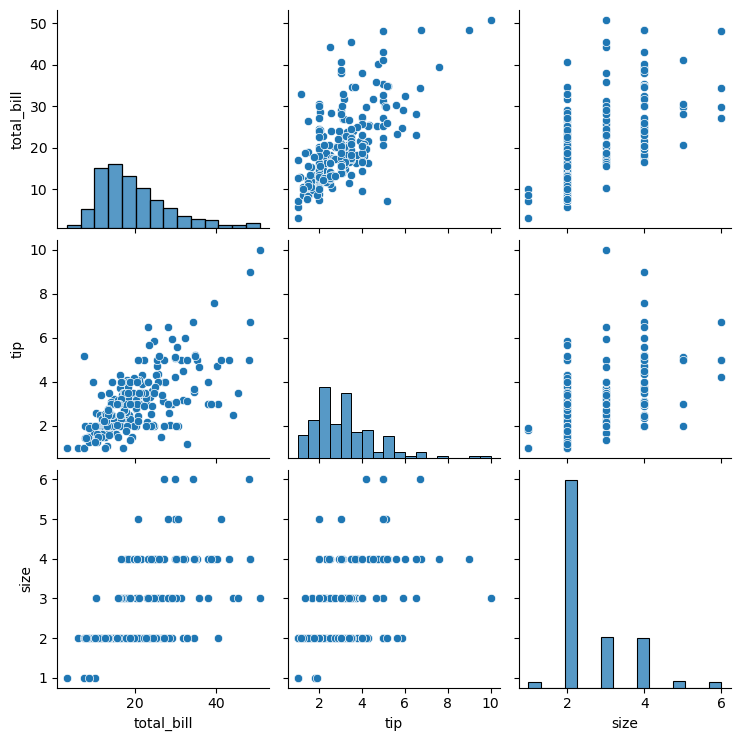

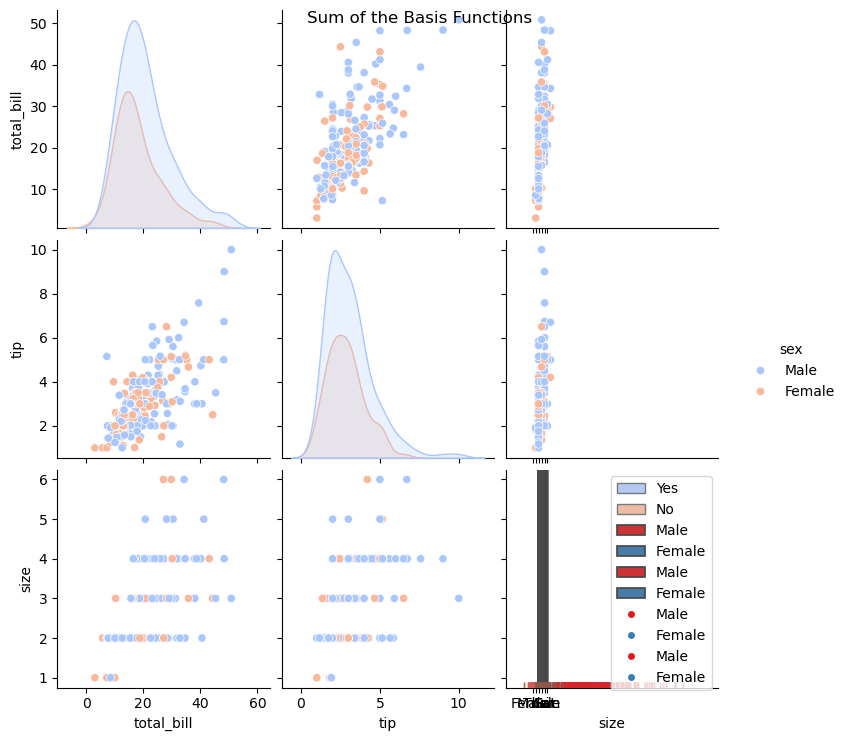

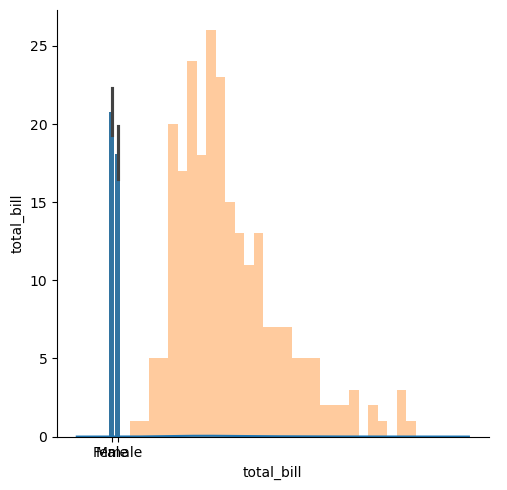

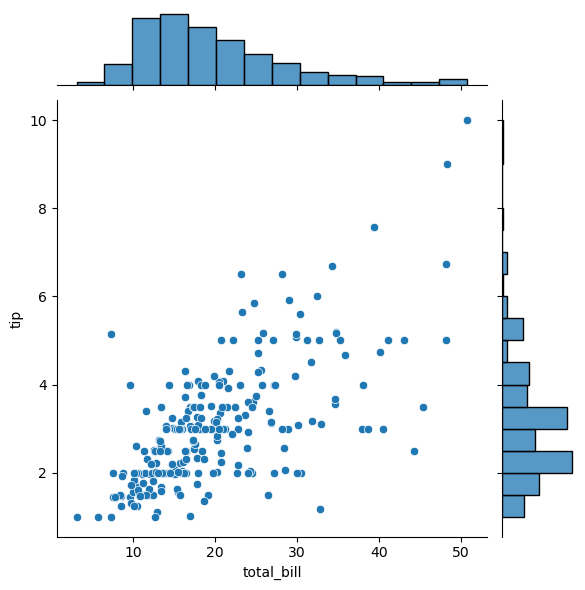

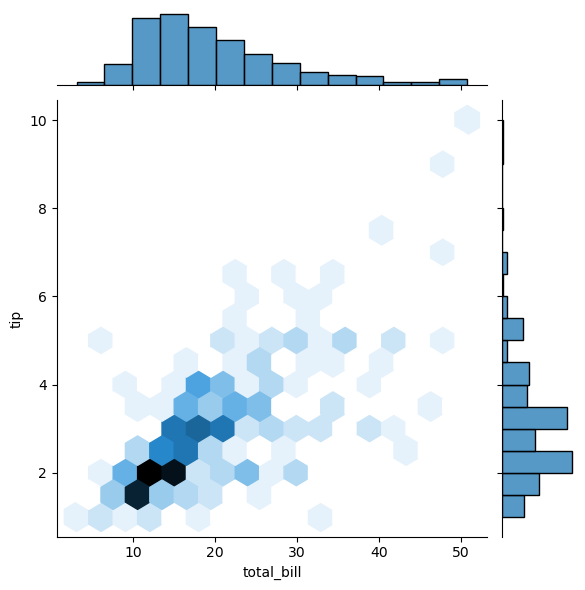

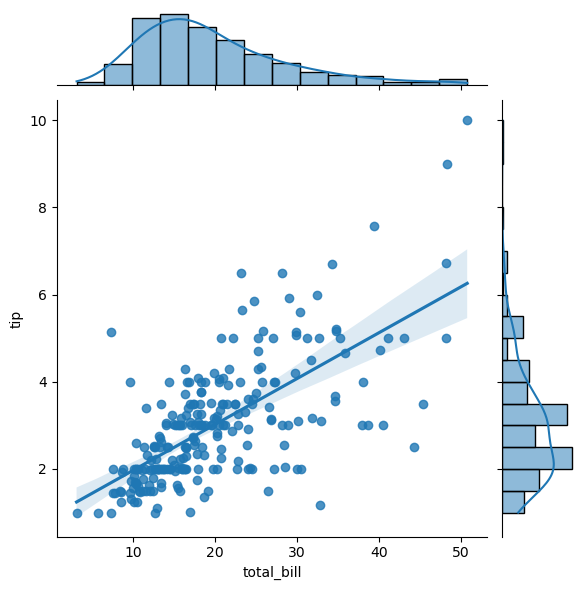

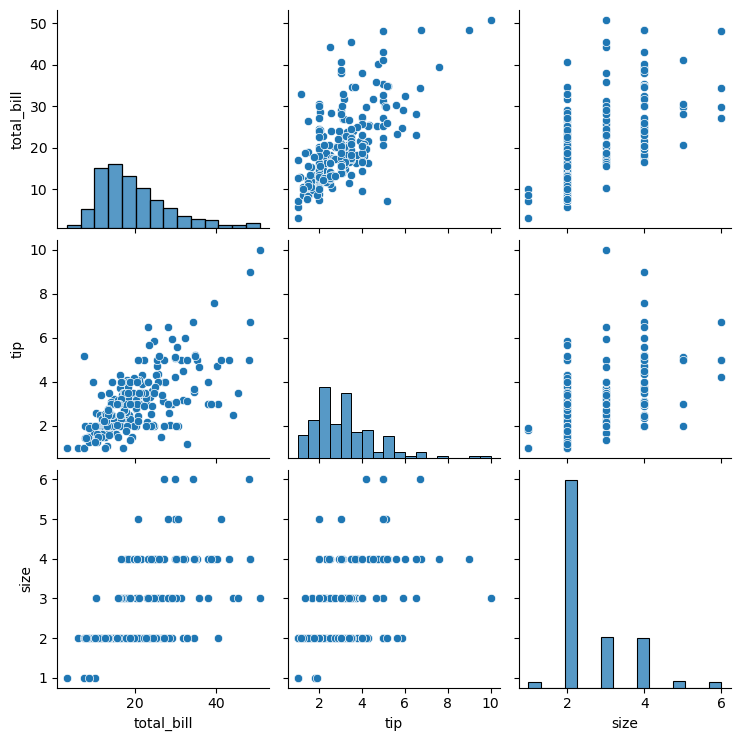

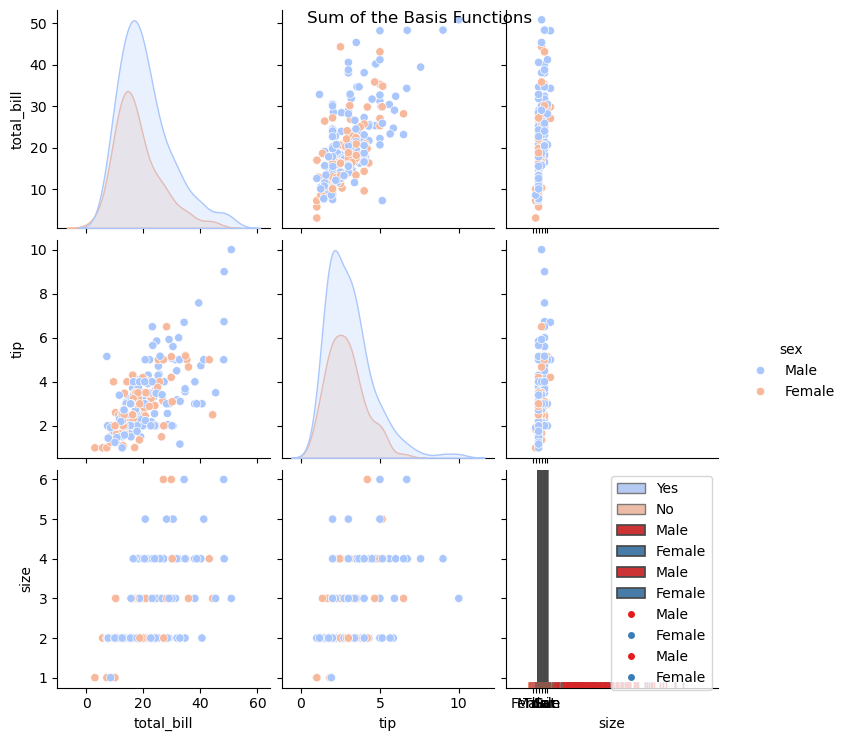

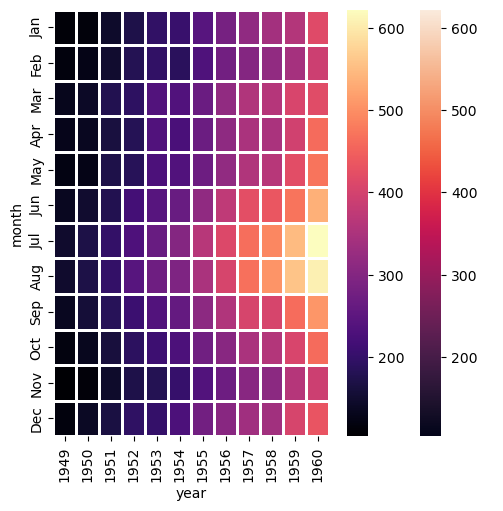

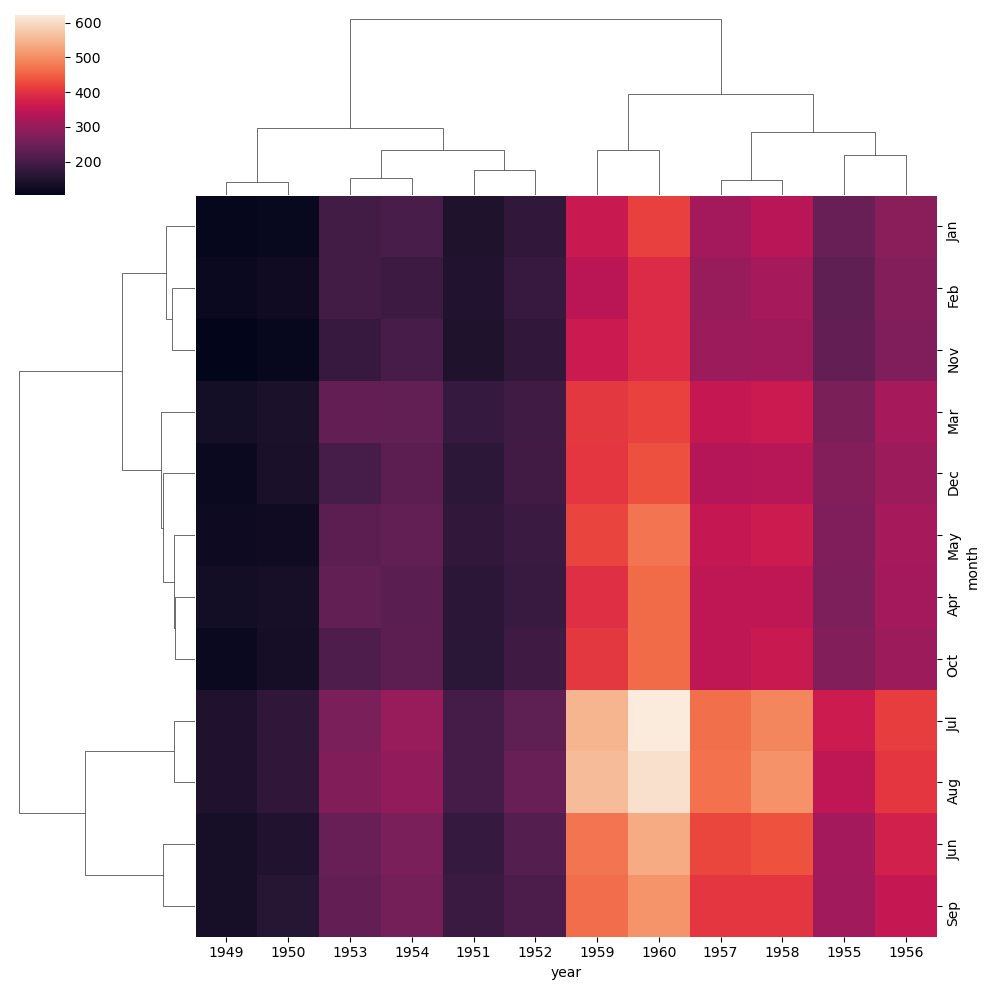

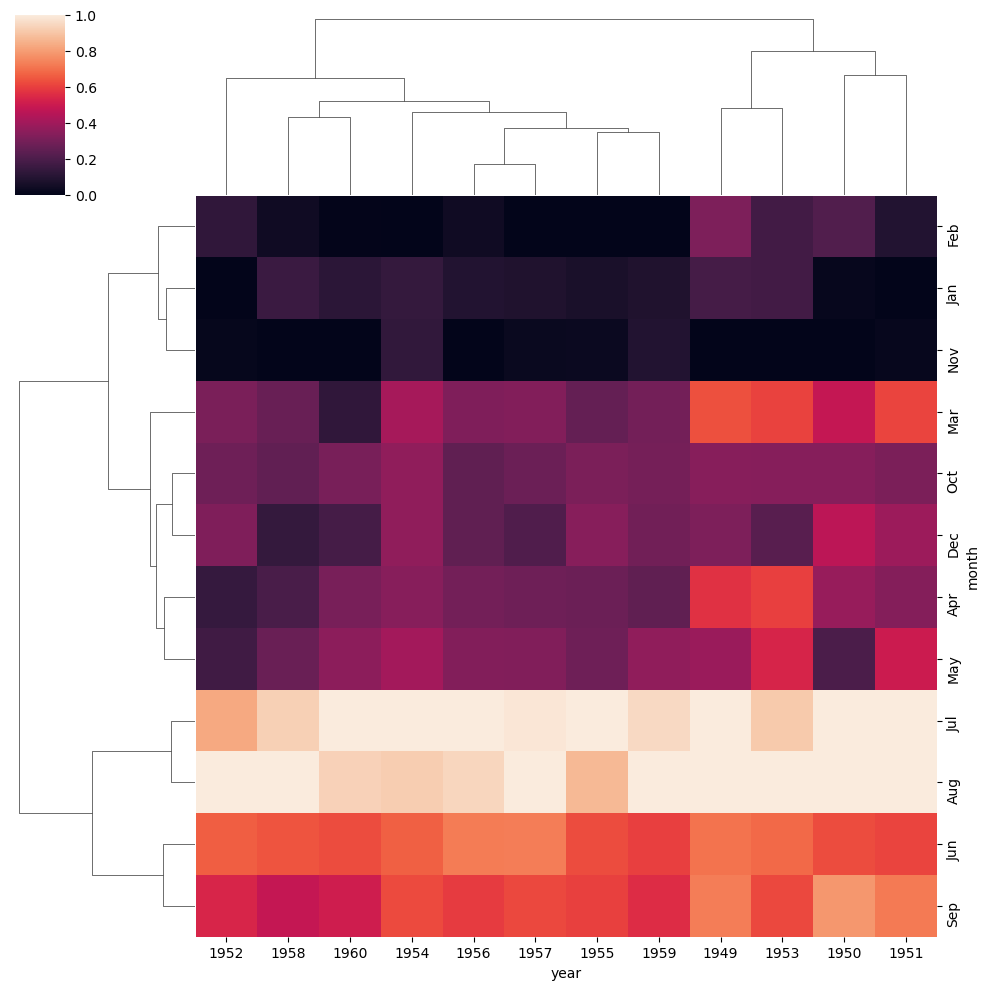

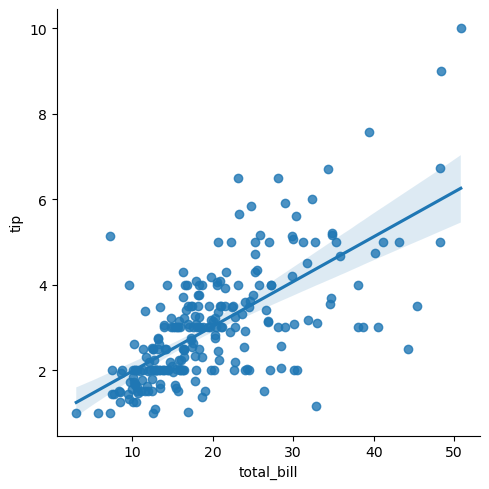

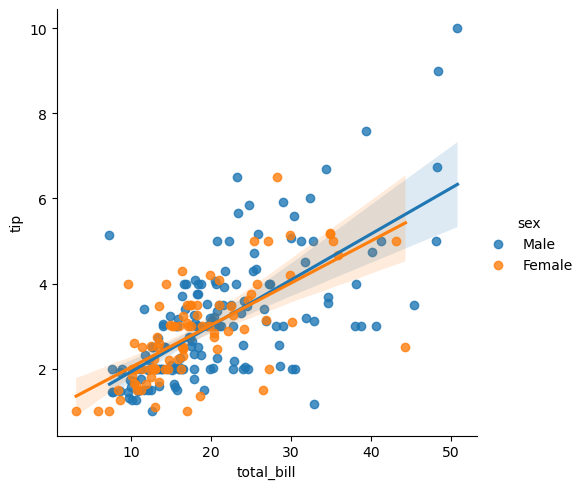

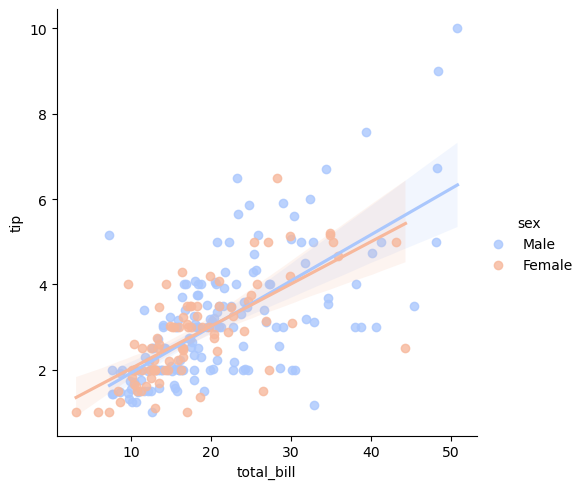

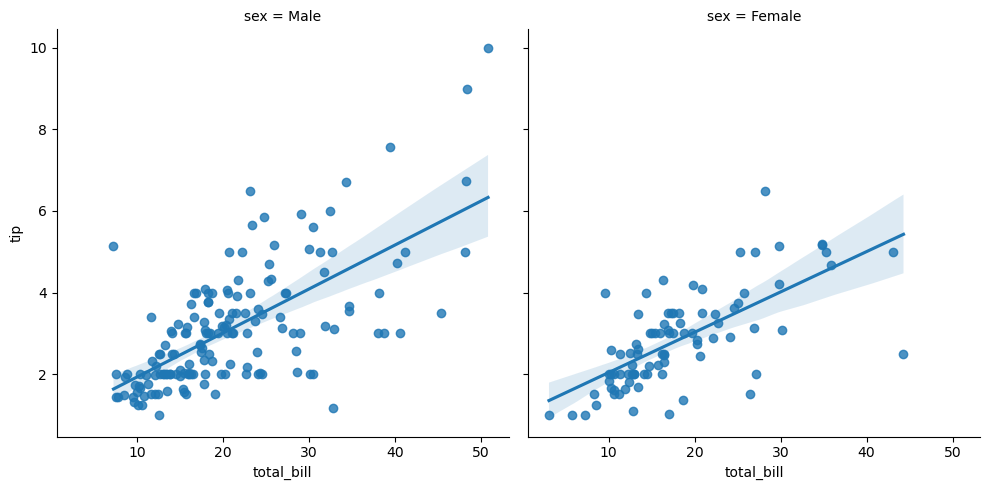

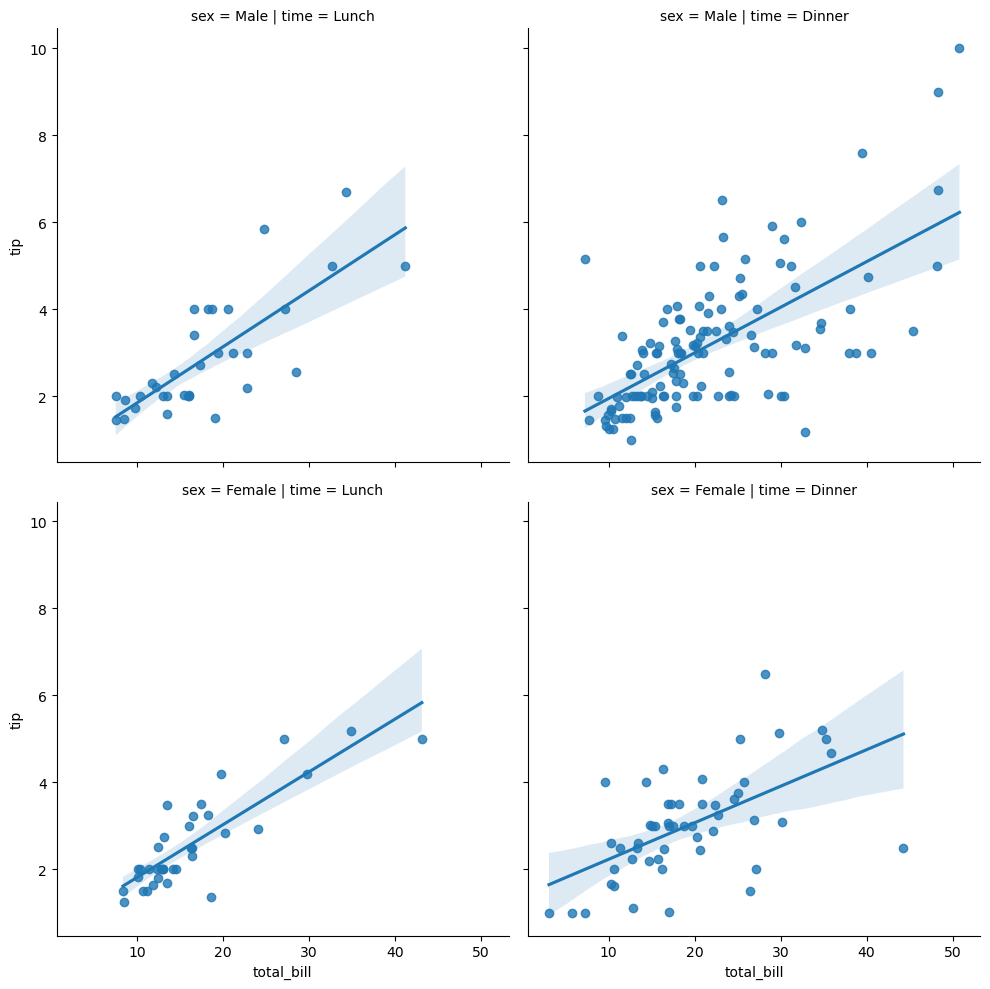

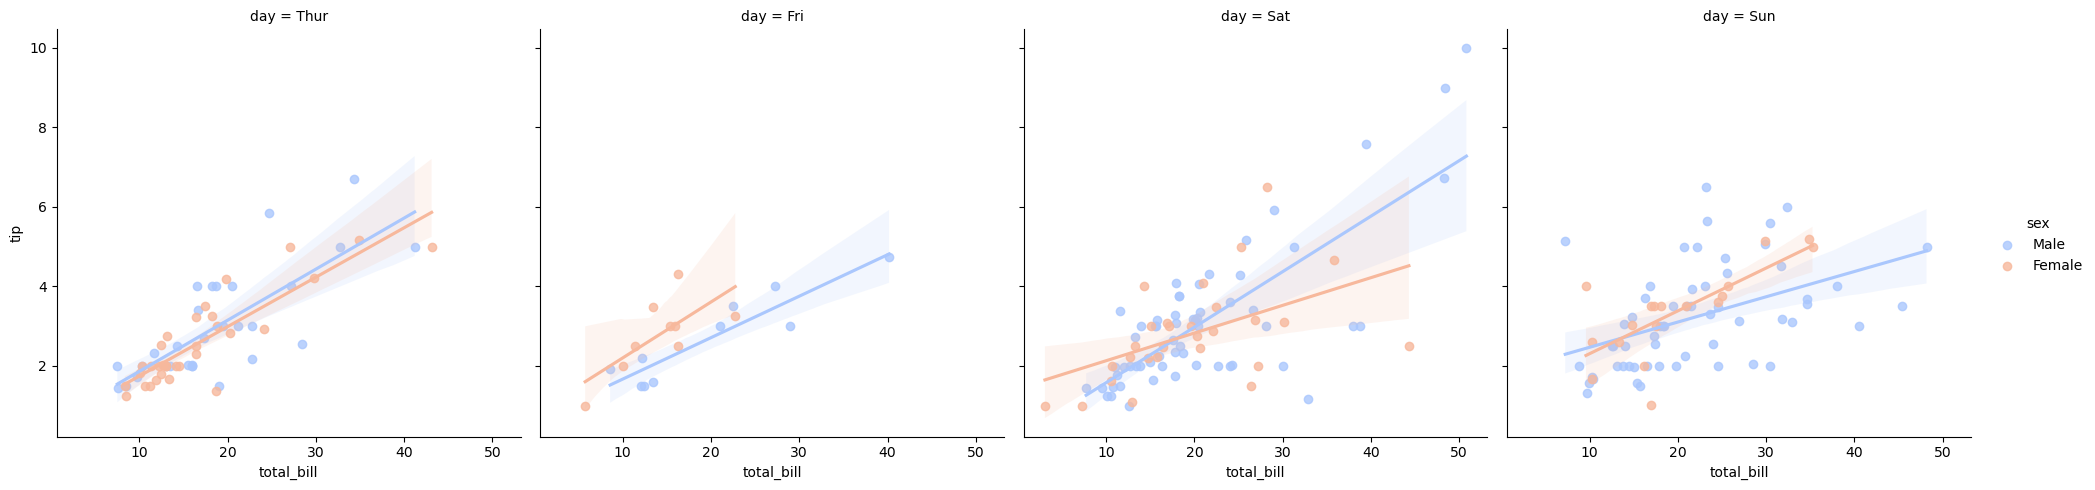

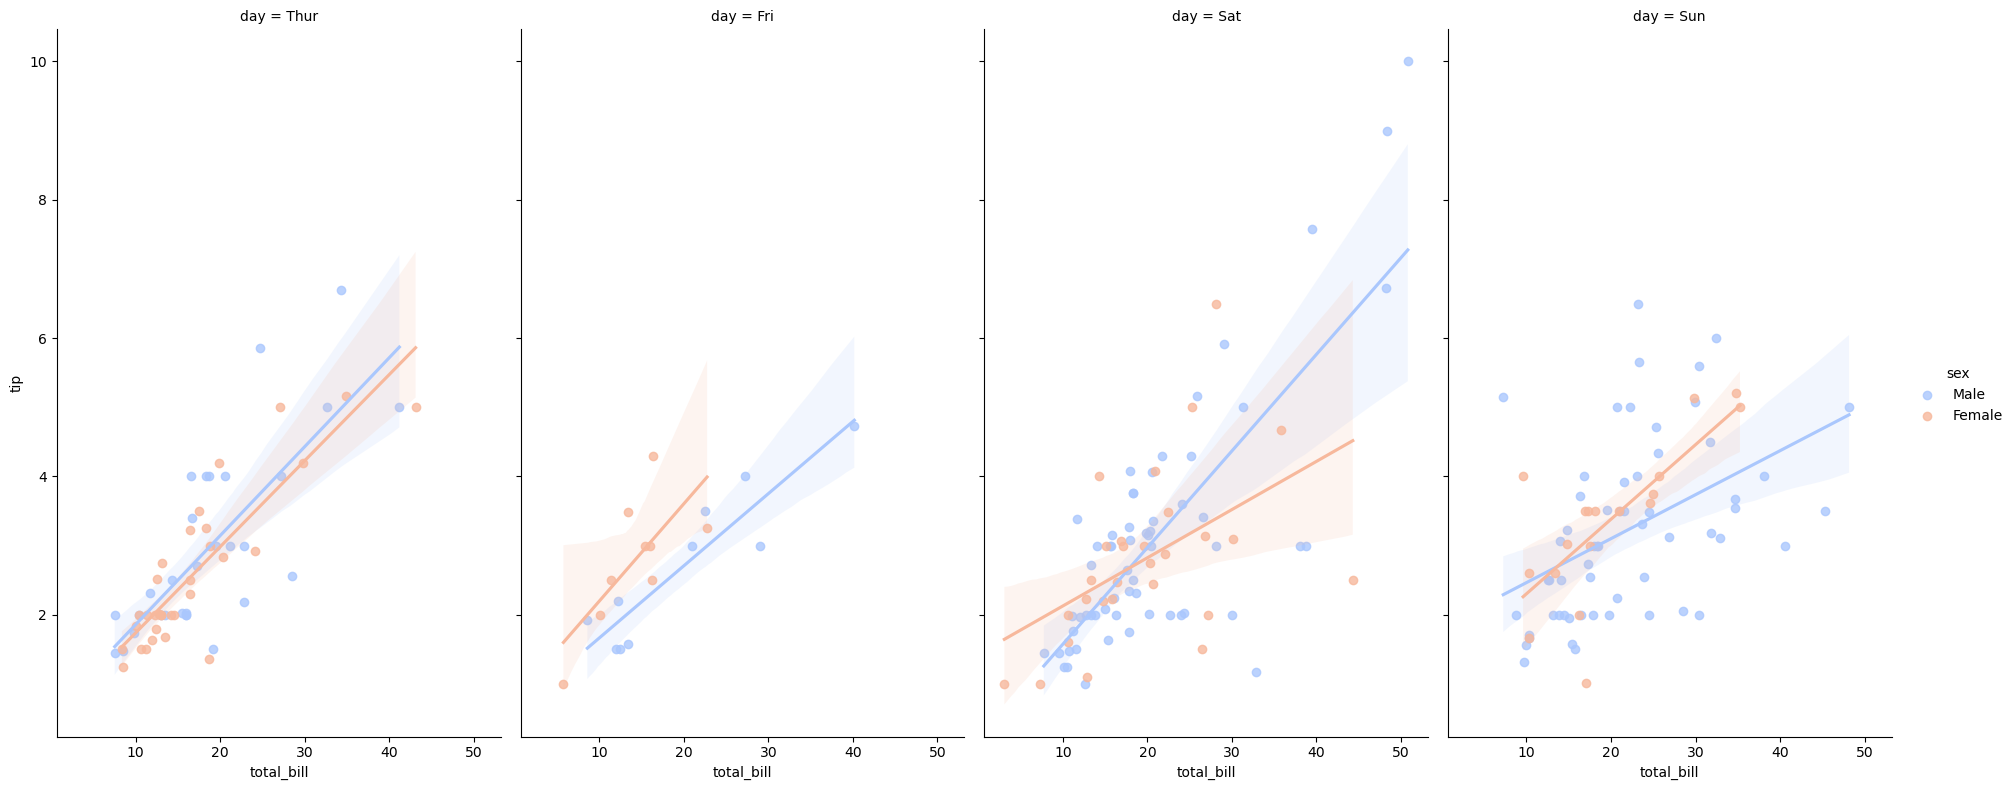

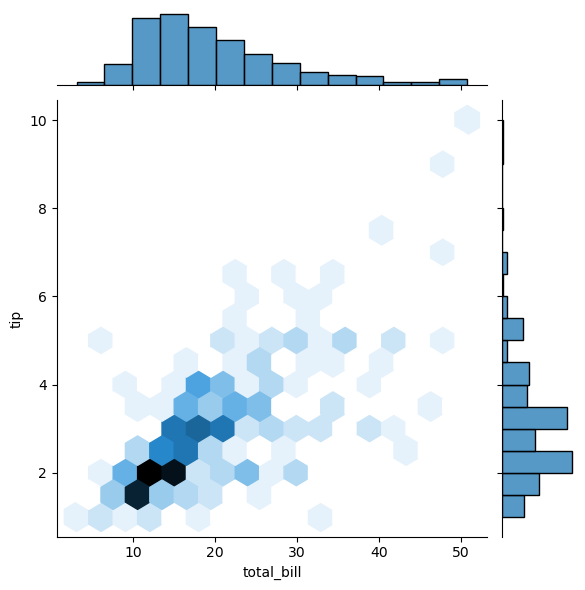

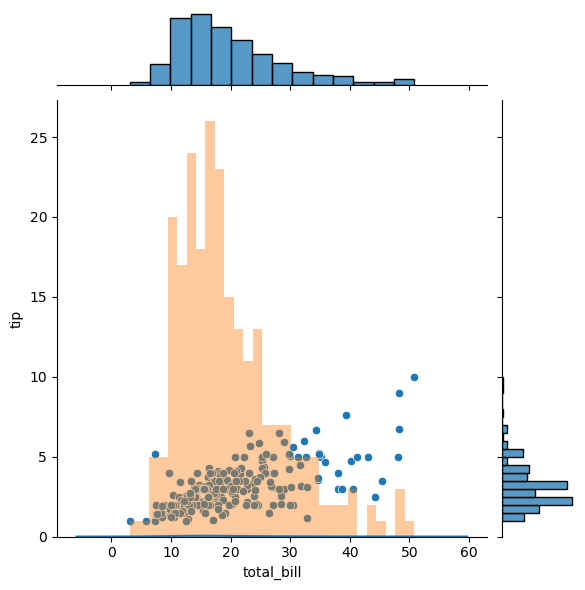

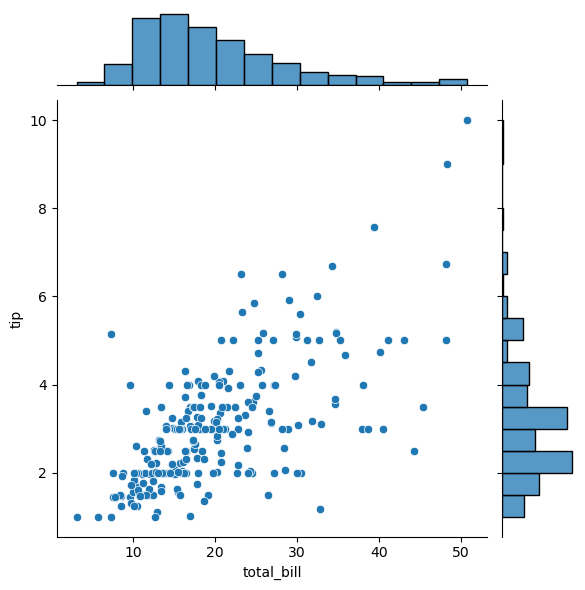

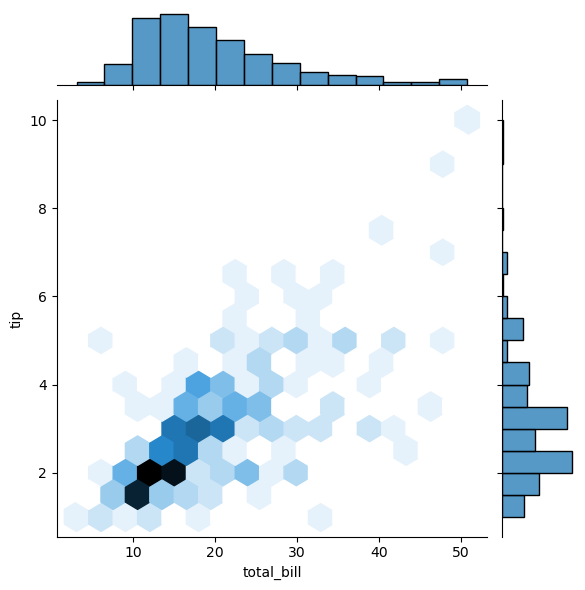

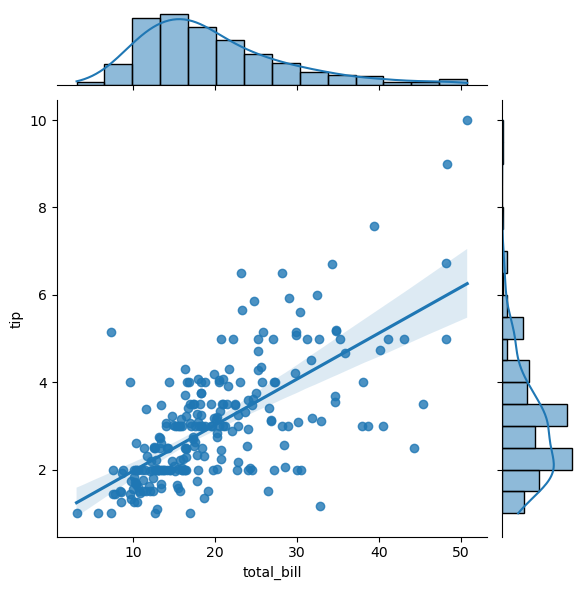

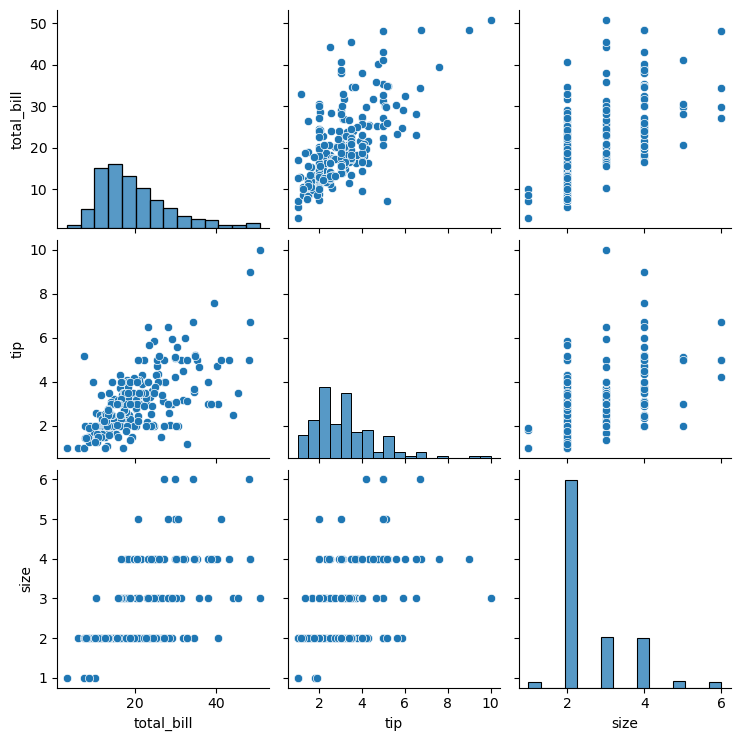

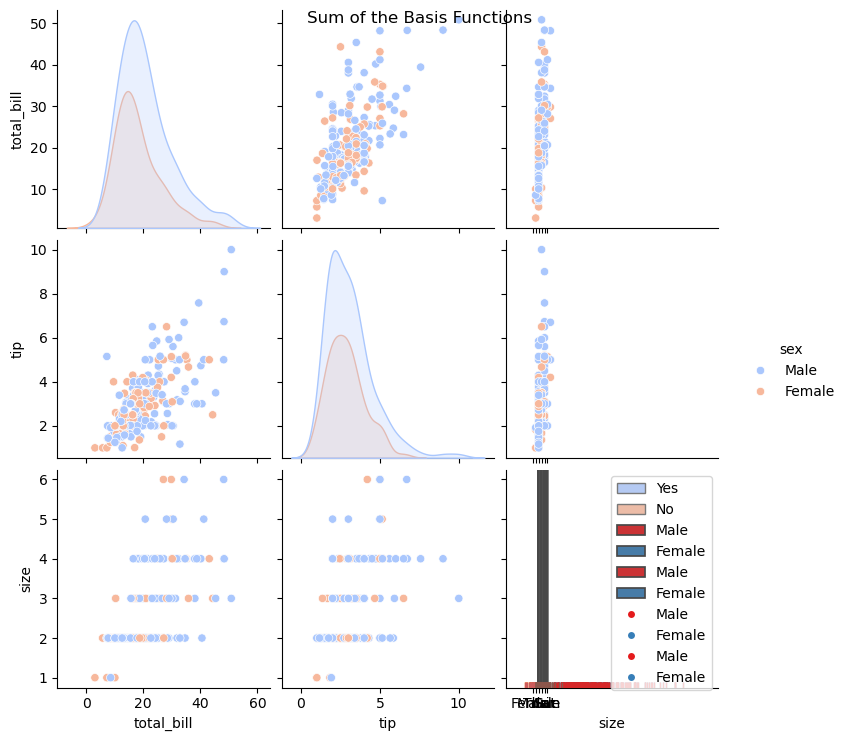

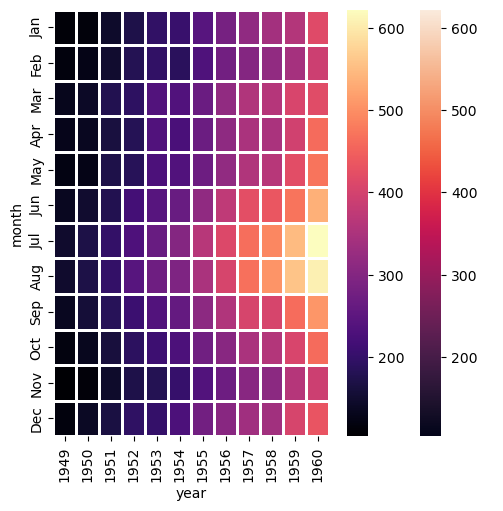

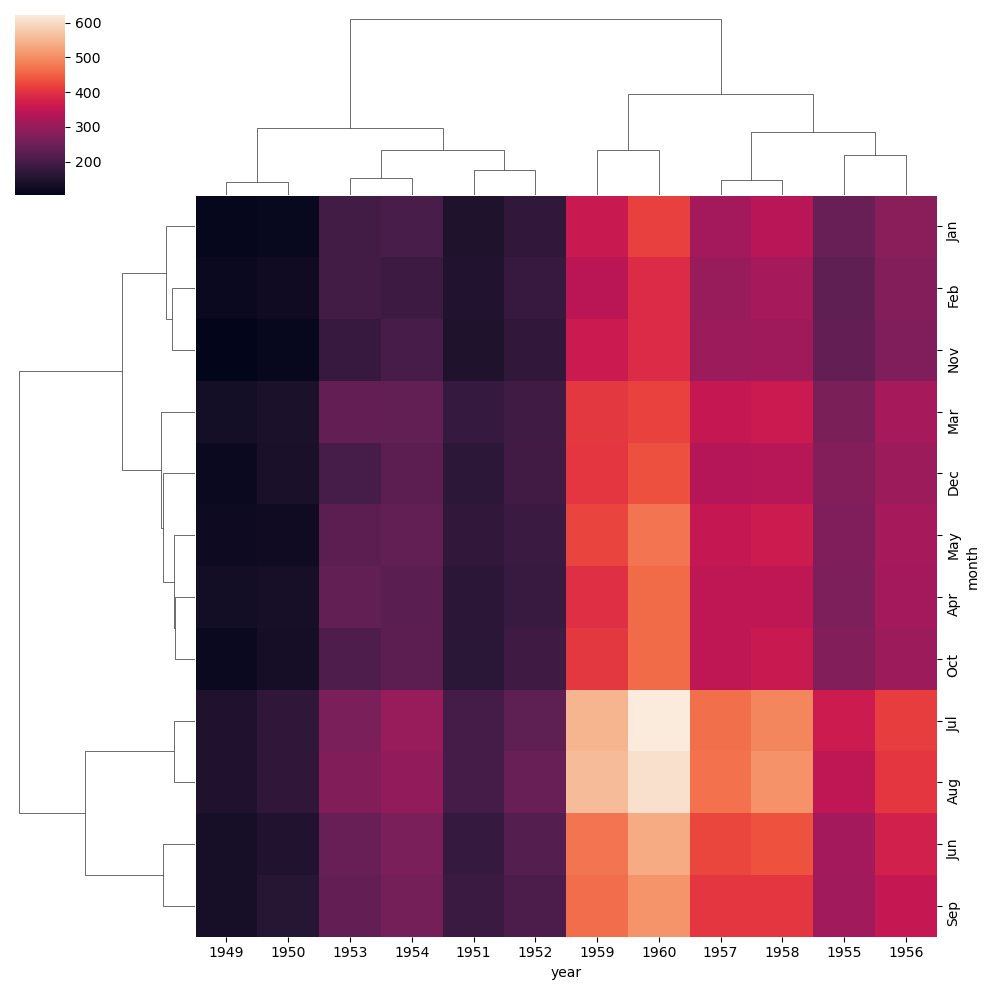

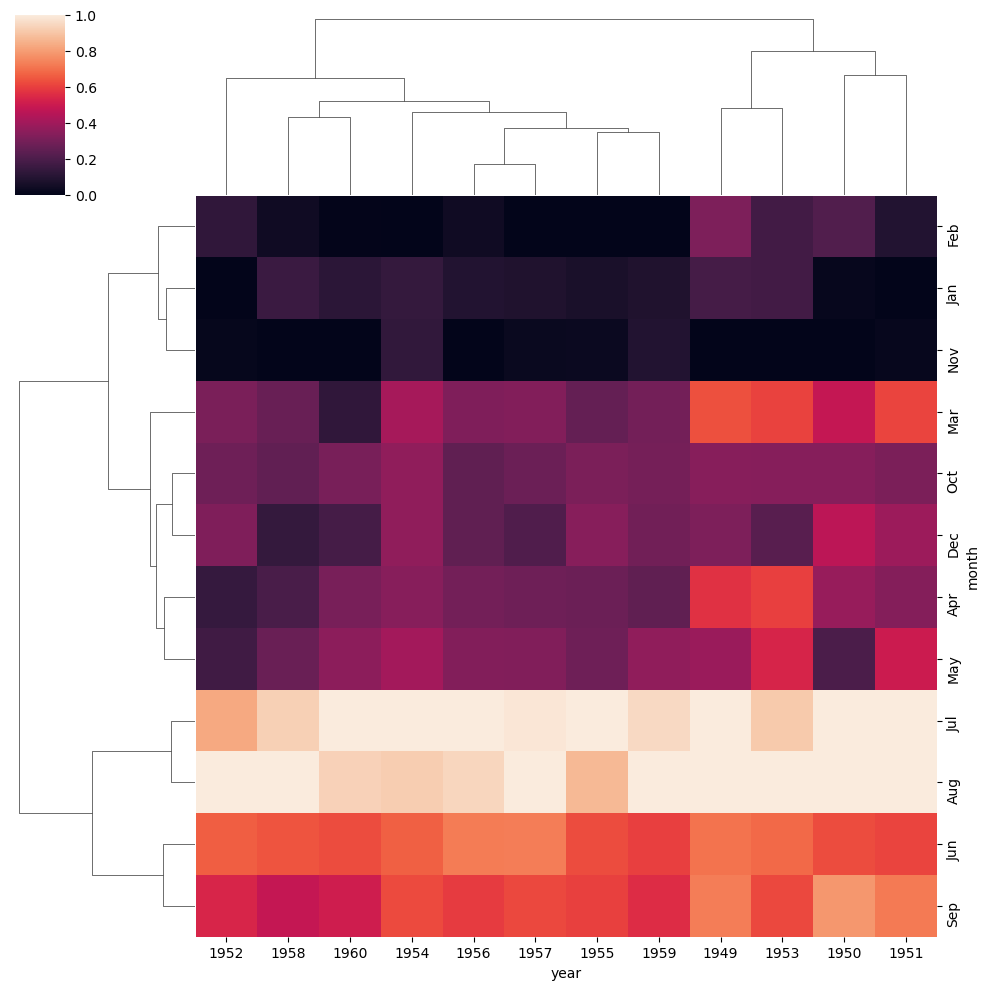

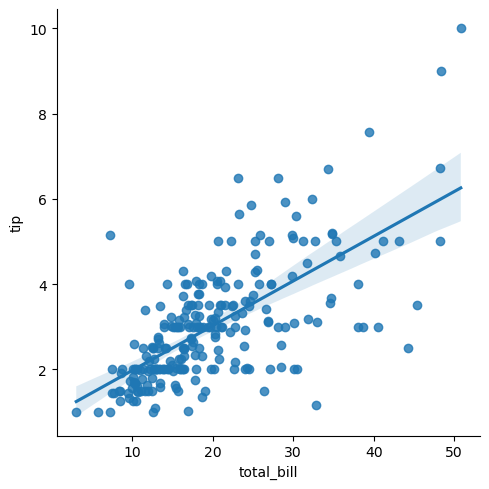

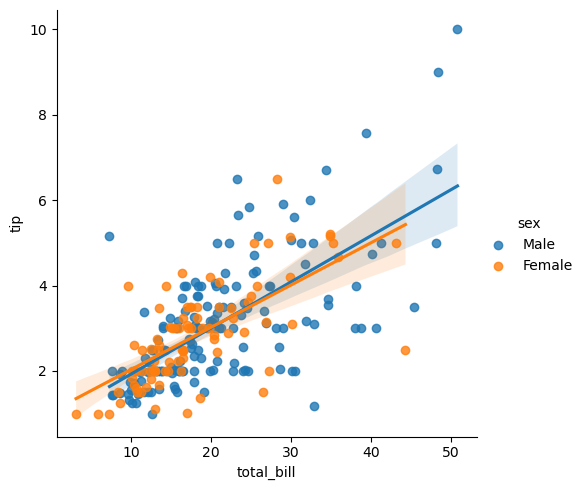

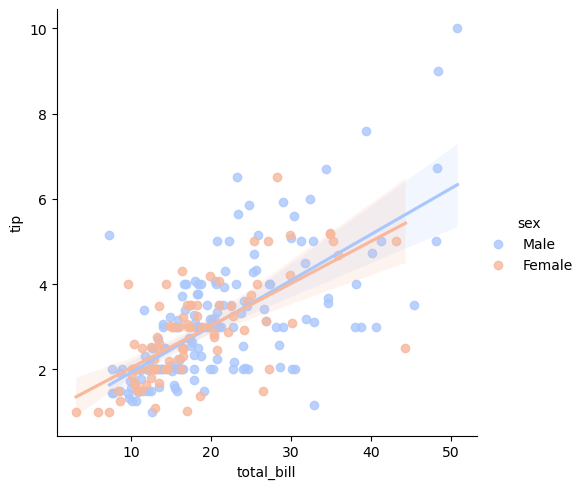

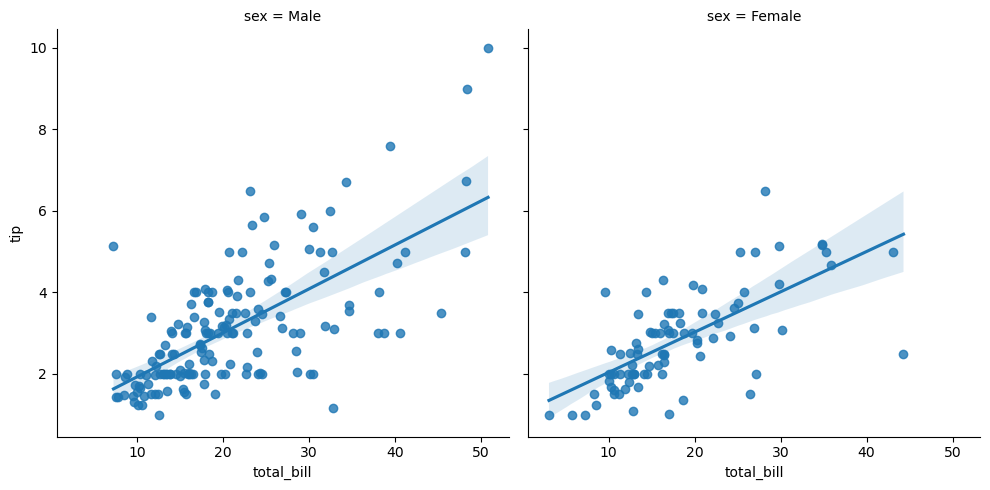

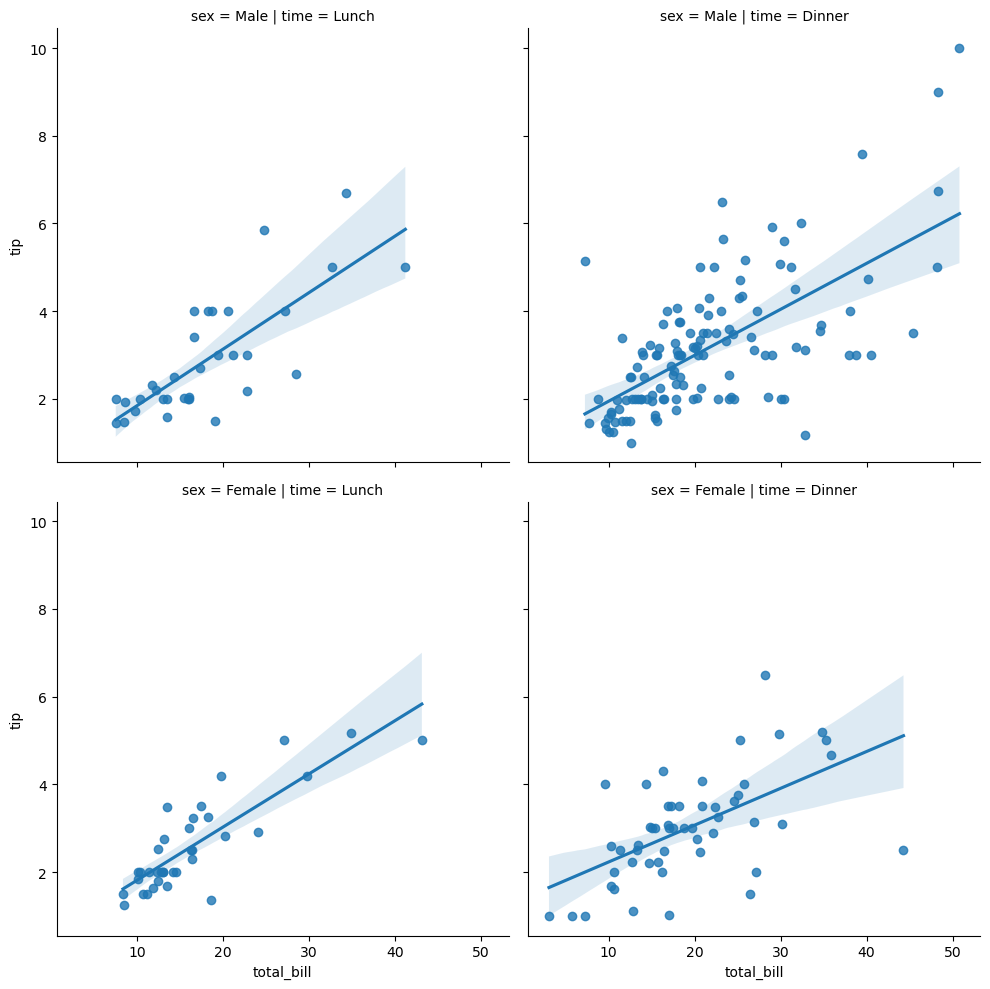

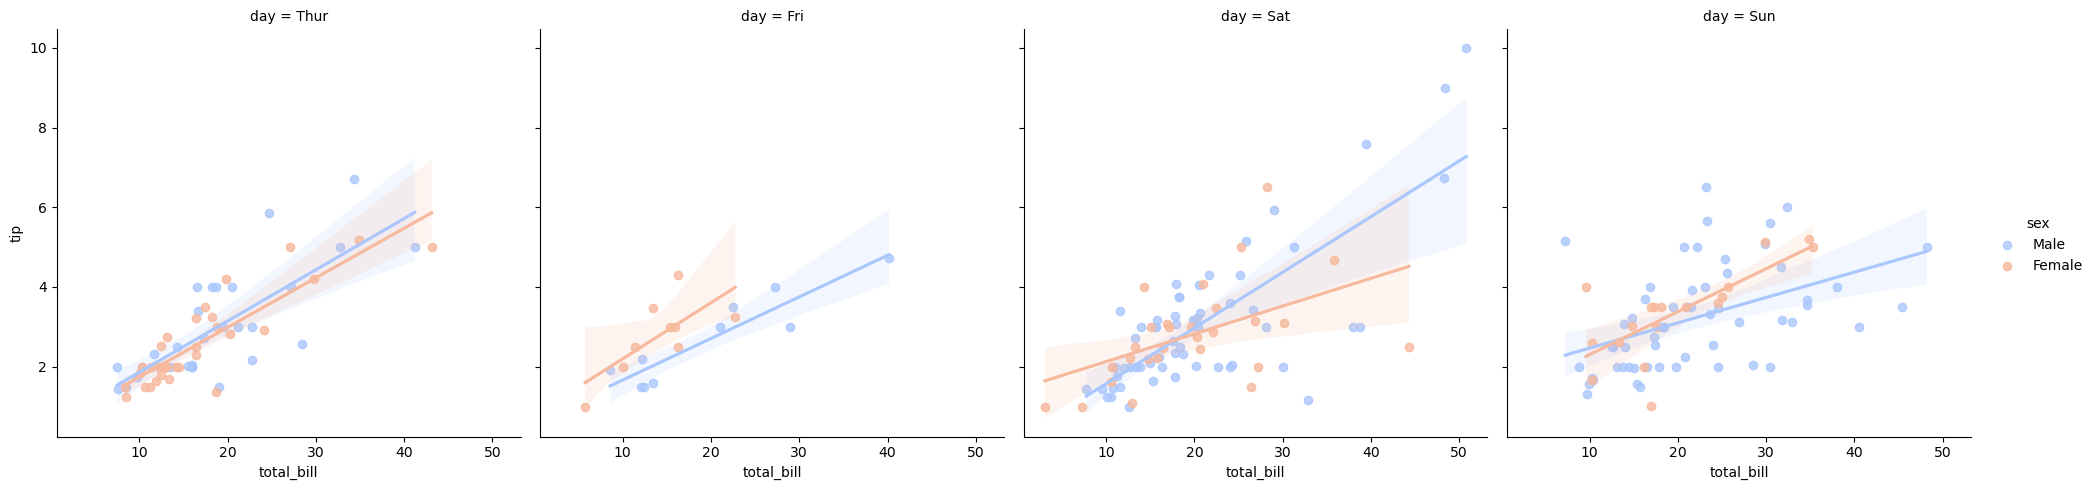

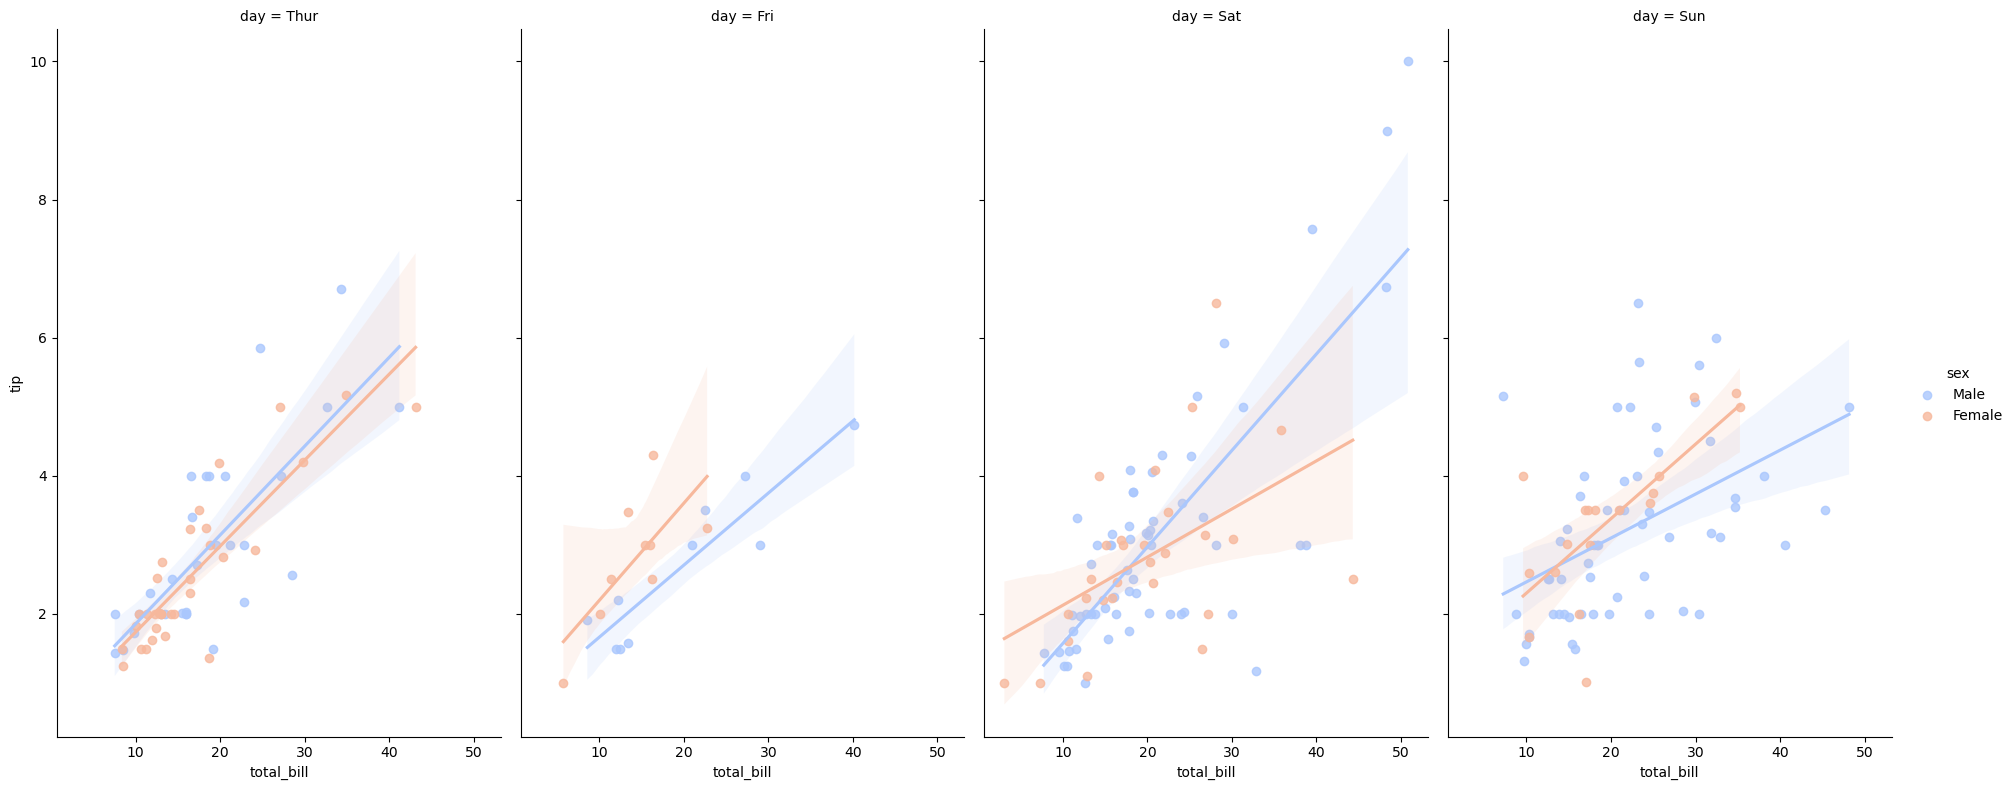

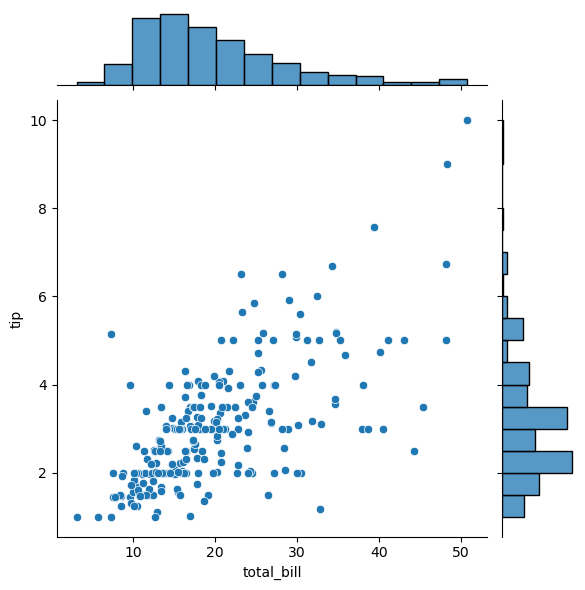

In [ ]:
%matplotlib inline
sns.jointplot(x='total_bill',y='tip',data=tips,kind='scatter')
plt.show()
# total bill jointplot compared with the scatter parameter


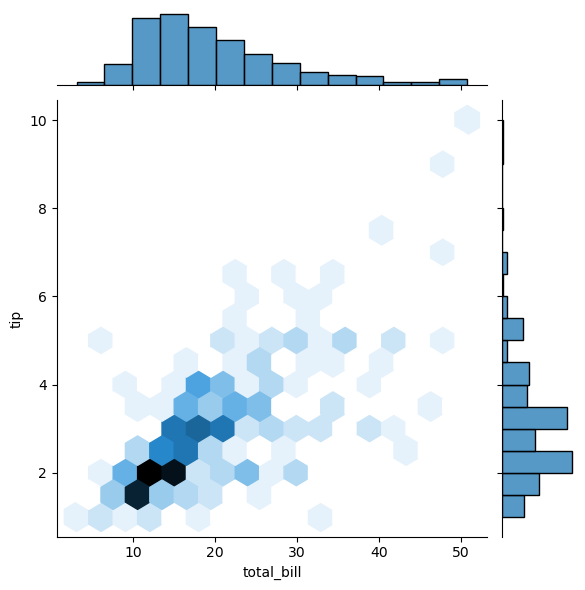

In [ ]:
#sns.jointplot(x='total_bill',y='tip',data=tips,kind='hex')
sns.jointplot(x='total_bill', y='tip', data=tips, kind='hex', height=6)
plt.show()
# total bill jointplot compared with the scatter parameter

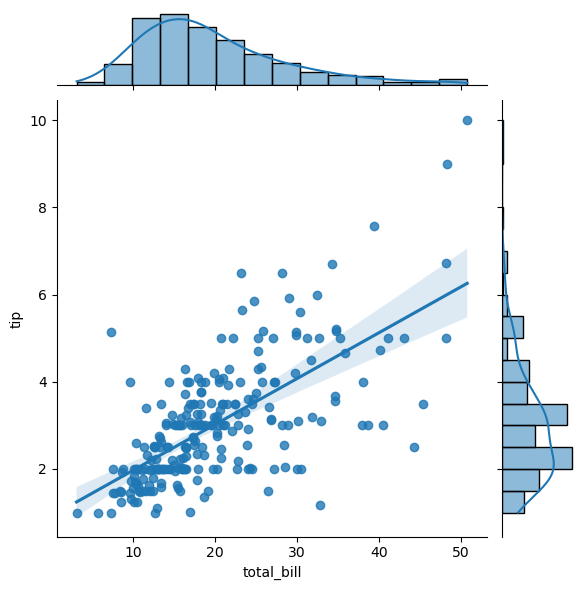

In [ ]:
sns.jointplot(x='total_bill',y='tip',data=tips,kind='reg')
plt.show()
# total bill jointplot compared with the reg parameter

## pairplot

pairplot will plot pairwise relationships across an entire dataframe (for the numerical columns) and supports a color hue argument (for categorical columns). 

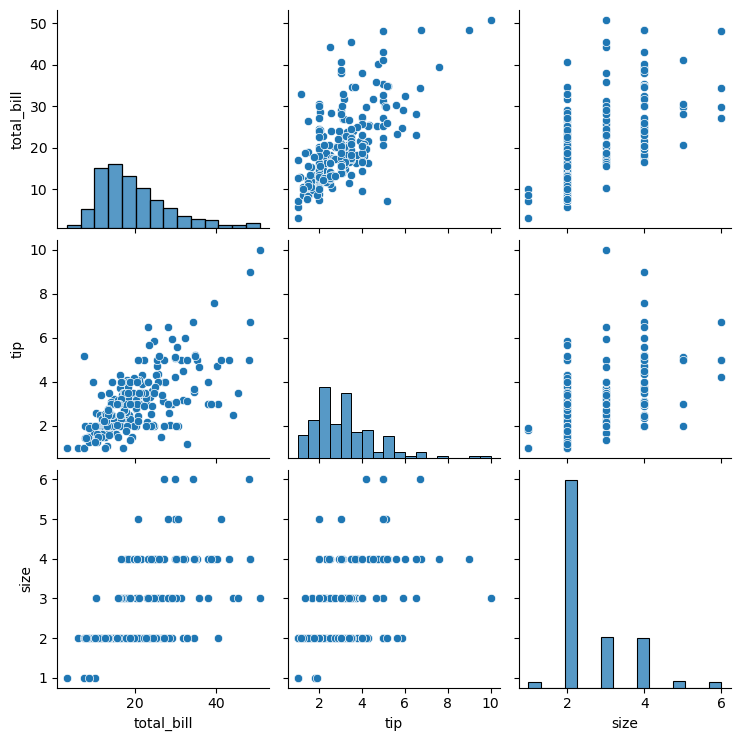

In [ ]:
sns.pairplot(tips)
plt.show()
#showing the pair plot

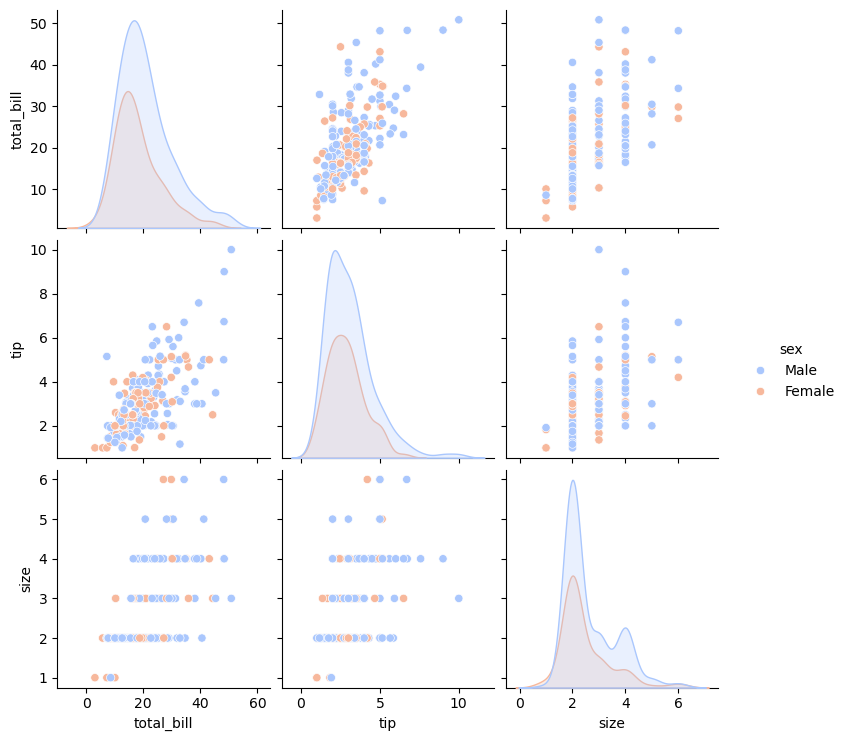

In [ ]:
sns.pairplot(tips,hue='sex',palette='coolwarm')
plt.show()

#pairplot with a different hue and plaette 

## rugplot

rugplots are actually a very simple concept, they just draw a dash mark for every point on a univariate distribution. They are the building block of a KDE plot:

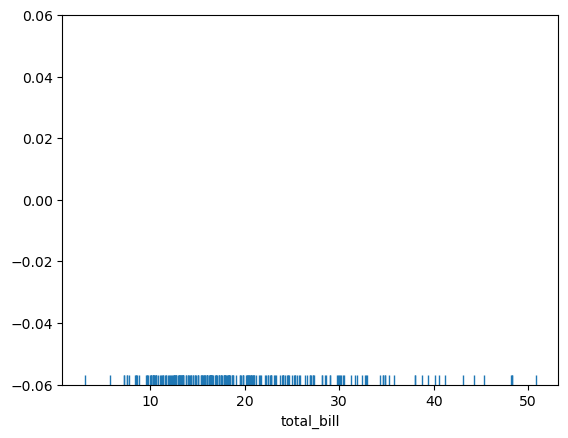

In [ ]:
sns.rugplot(tips['total_bill']) #rugplot graph
plt.show()

## kdeplot

kdeplots are [Kernel Density Estimation plots](http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth). These KDE plots replace every single observation with a Gaussian (Normal) distribution centered around that value. For example:

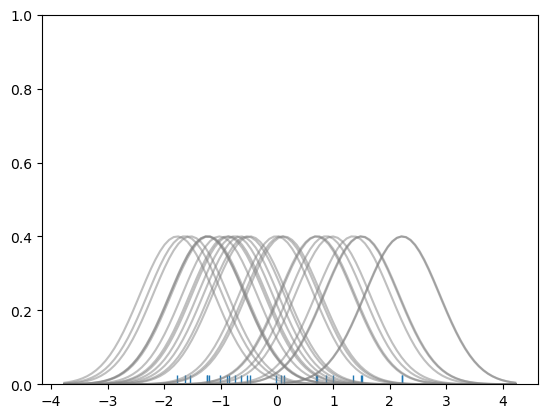

In [251]:
# Don't worry about understanding this code!
# It's just for the diagram below
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

#Create dataset
dataset = np.random.randn(25)

# Create another rugplot
sns.rugplot(dataset);

# Set up the x-axis for the plot
x_min = dataset.min() - 2
x_max = dataset.max() + 2

# 100 equally spaced points from x_min to x_max
x_axis = np.linspace(x_min,x_max,100)

# Set up the bandwidth, for info on this:
url = 'http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth'

bandwidth = ((4*dataset.std()**5)/(3*len(dataset)))**.2


# Create an empty kernel list
kernel_list = []

# Plot each basis function
for data_point in dataset:
    
    # Create a kernel for each point and append to list
    kernel = stats.norm(data_point,bandwidth).pdf(x_axis)
    kernel_list.append(kernel)
    
    #Scale for plotting
    kernel = kernel / kernel.max()
    kernel = kernel * .4
    plt.plot(x_axis,kernel,color = 'grey',alpha=0.5)

plt.ylim(0,1)
plt.show()

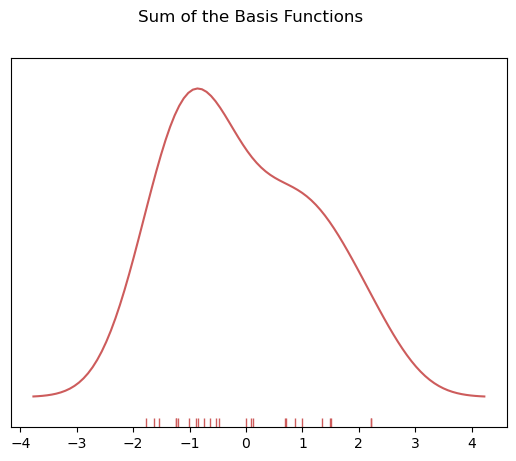

In [252]:
# To get the kde plot we can sum these basis functions.

# Plot the sum of the basis function
sum_of_kde = np.sum(kernel_list,axis=0)

# Plot figure
fig = plt.plot(x_axis,sum_of_kde,color='indianred')

# Add the initial rugplot
sns.rugplot(dataset,c = 'indianred')

# Get rid of y-tick marks
plt.yticks([])

# Set title
plt.suptitle("Sum of the Basis Functions")

plt.show()

So with our tips dataset:

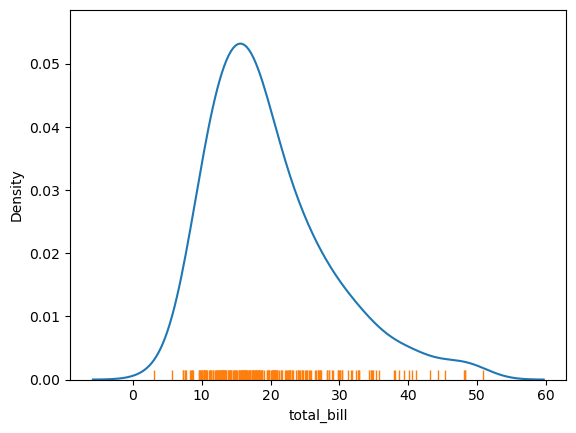

In [ ]:
sns.kdeplot(tips['total_bill'])
sns.rugplot(tips['total_bill'])
plt.show()
#the total bill kde plot overlayed with it's rug plot 

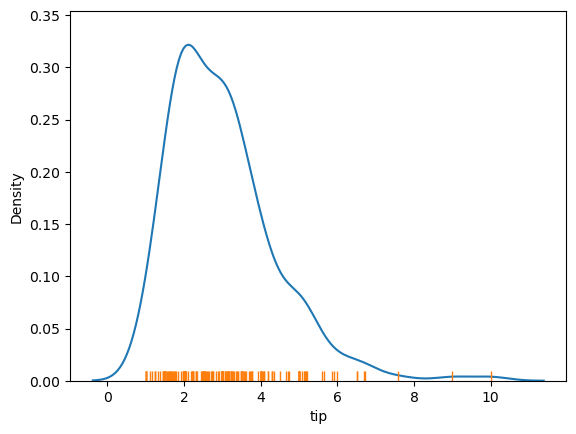

In [ ]:
sns.kdeplot(tips['tip'])
sns.rugplot(tips['tip'])

plt.show()
#the tips kde plot overlayed with it's rug plot 

# Categorical Data Plots

Now let's discuss using seaborn to plot categorical data! There are a few main plot types for this:

* factorplot
* boxplot
* violinplot
* stripplot
* swarmplot
* barplot
* countplot

Let's go through examples of each!

In [ ]:
import seaborn as sns # imports
%matplotlib inline

In [ ]:
tips = sns.load_dataset('tips')
tips.head()
#showing the dataset


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## barplot and countplot

These very similar plots allow you to get aggregate data off a categorical feature in your data. **barplot** is a general plot that allows you to aggregate the categorical data based off some function, by default the mean:

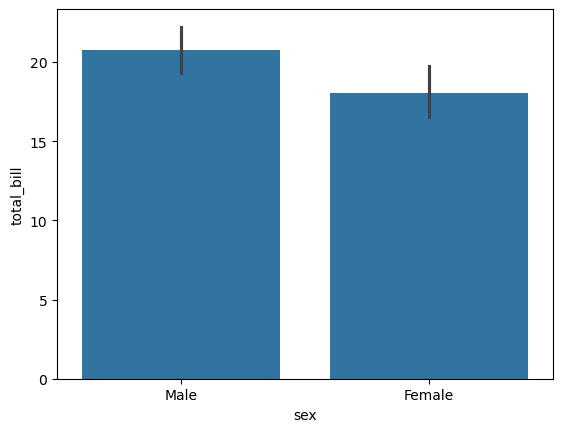

In [ ]:
sns.barplot(x='sex',y='total_bill',data=tips)
plt.show()
#showing tips in the box plot using the total bill and the sex from the dataset

In [ ]:
import numpy as np 
#imports

You can change the estimator object to your own function, that converts a vector to a scalar:

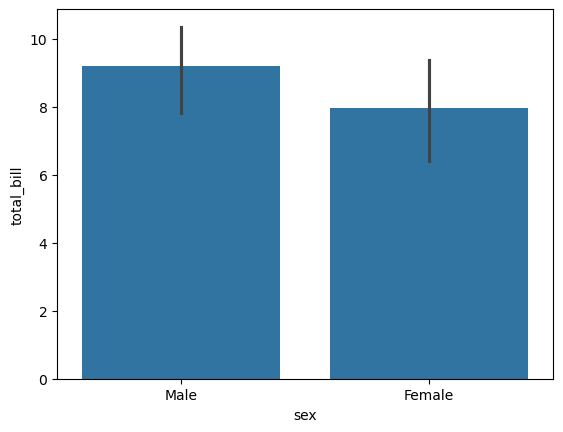

In [ ]:
sns.barplot(x='sex',y='total_bill',data=tips,estimator=np.std)
plt.show()
#same as before but with changes to the estimator function that converts a vector to scalar

### countplot

This is essentially the same as barplot except the estimator is explicitly counting the number of occurrences. Which is why we only pass the x value:

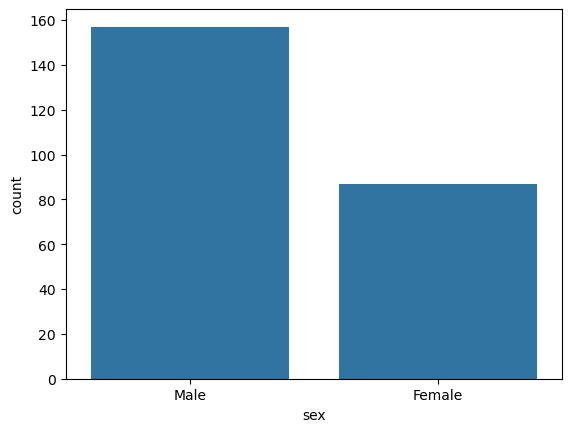

In [ ]:
sns.countplot(x='sex',data=tips)
plt.show()
#the countplot of tips of males and females

## boxplot and violinplot

boxplots and violinplots are used to shown the distribution of categorical data. A box plot (or box-and-whisker plot) shows the distribution of quantitative data in a way that facilitates comparisons between variables or across levels of a categorical variable. The box shows the quartiles of the dataset while the whiskers extend to show the rest of the distribution, except for points that are determined to be “outliers” using a method that is a function of the inter-quartile range.

C:\Users\almok\AppData\Local\Temp\ipykernel_21544\1605400575.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="day", y="total_bill", data=tips,palette='rainbow')


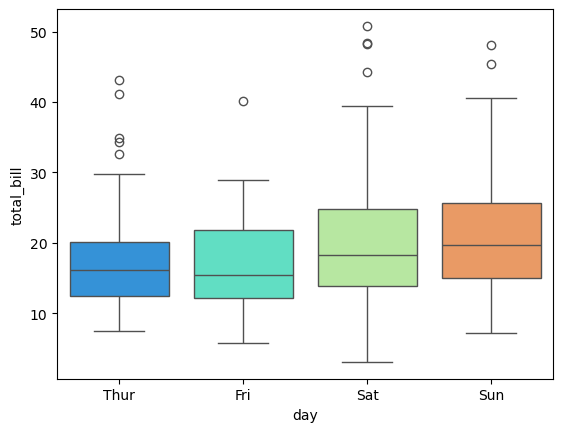

In [ ]:
sns.boxplot(x="day", y="total_bill", data=tips,palette='rainbow')
plt.show()

#a boxplot of tips based on total bills and days of the week 

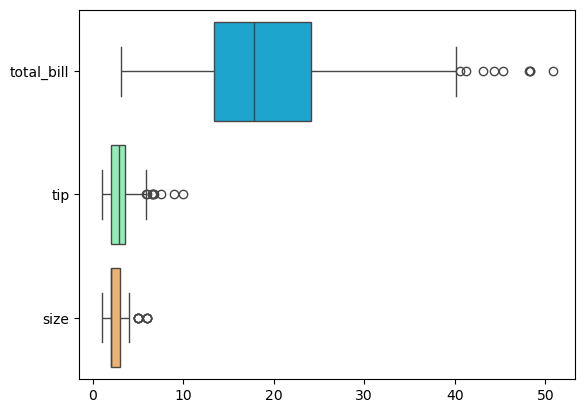

In [259]:
# Can do entire dataframe with orient='h'
sns.boxplot(data=tips,palette='rainbow',orient='h')
plt.show()

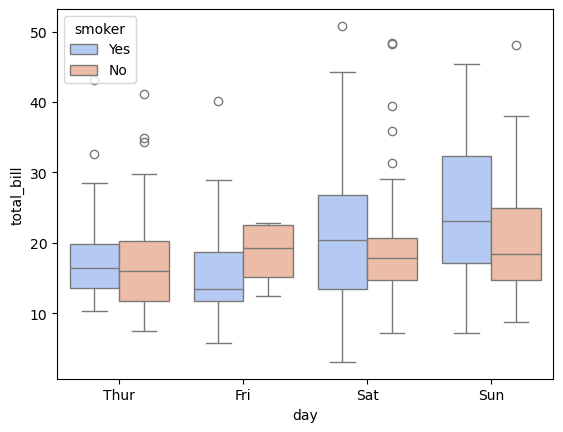

In [ ]:
sns.boxplot(x="day", y="total_bill", hue="smoker",data=tips, palette="coolwarm")
plt.show()
#a boxplot of tips based on total bills and if they smoke and days of the week 

### violinplot
A violin plot plays a similar role as a box and whisker plot. It shows the distribution of quantitative data across several levels of one (or more) categorical variables such that those distributions can be compared. Unlike a box plot, in which all of the plot components correspond to actual datapoints, the violin plot features a kernel density estimation of the underlying distribution.

C:\Users\almok\AppData\Local\Temp\ipykernel_21544\1628878234.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="day", y="total_bill", data=tips,palette='rainbow')


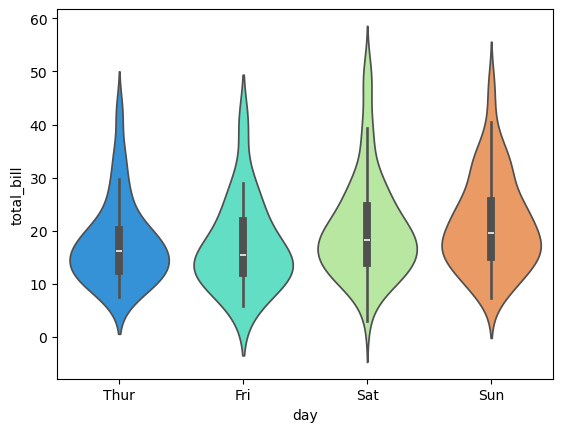

In [ ]:
sns.violinplot(x="day", y="total_bill", data=tips,palette='rainbow')
plt.show()
#showing a violin plot of total bill per day

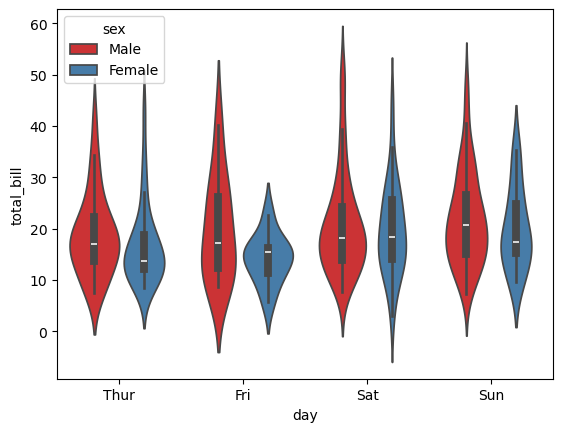

In [ ]:
sns.violinplot(x="day", y="total_bill", data=tips,hue='sex',palette='Set1')
plt.show()
#showing the same plot as before but it is split into male and female

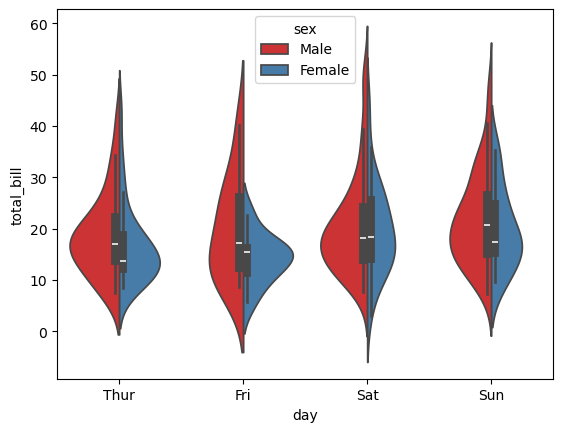

In [ ]:
sns.violinplot(x="day", y="total_bill", data=tips,hue='sex',split=True,palette='Set1')
plt.show()
#this time the male and female are joined

## stripplot and swarmplot
The stripplot will draw a scatterplot where one variable is categorical. A strip plot can be drawn on its own, but it is also a good complement to a box or violin plot in cases where you want to show all observations along with some representation of the underlying distribution.

The swarmplot is similar to stripplot(), but the points are adjusted (only along the categorical axis) so that they don’t overlap. This gives a better representation of the distribution of values, although it does not scale as well to large numbers of observations (both in terms of the ability to show all the points and in terms of the computation needed to arrange them).

C:\Users\almok\AppData\Local\Temp\ipykernel_21544\4087312803.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="day", y="total_bill", data=tips, palette='rainbow')


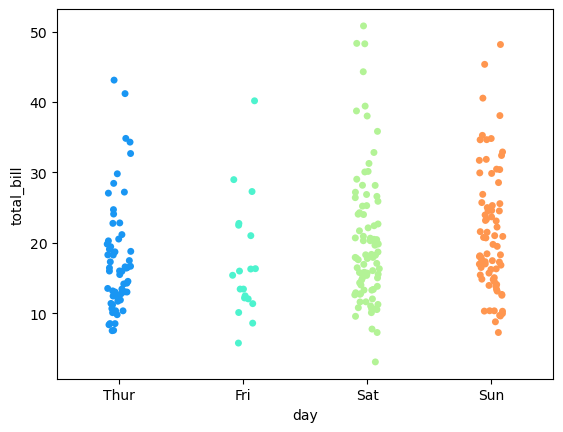

In [ ]:
sns.stripplot(x="day", y="total_bill", data=tips, palette='rainbow')
plt.show()
#stepplot of total bill per day

C:\Users\almok\AppData\Local\Temp\ipykernel_21544\1710301521.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="day", y="total_bill", data=tips,jitter=True, palette='rainbow')


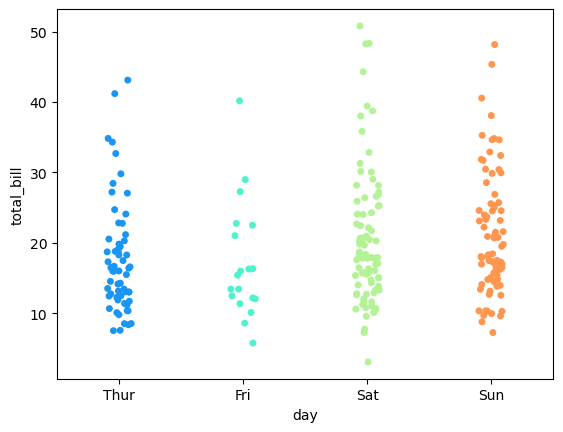

In [ ]:
sns.stripplot(x="day", y="total_bill", data=tips,jitter=True, palette='rainbow')
plt.show()
#stepplot of total bill per day with jitter being true

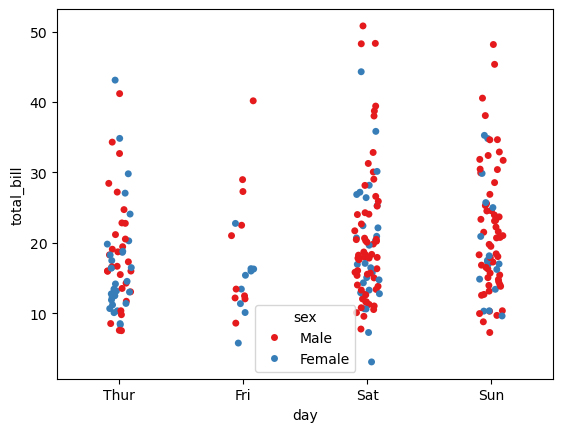

In [ ]:
sns.stripplot(x="day", y="total_bill", data=tips,jitter=True,hue='sex',palette='Set1')
plt.show()
#stepplot of total bill per day with jitter being true and split into the sexes

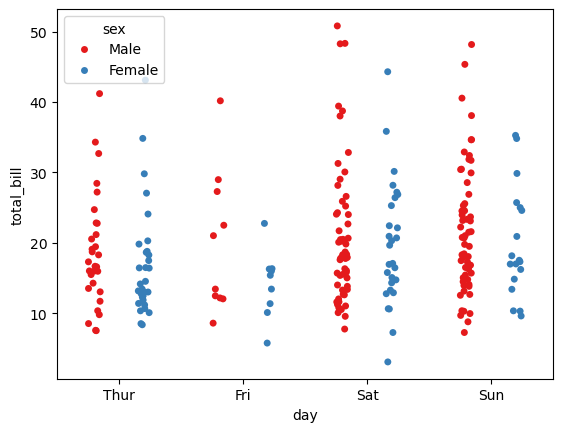

In [ ]:
sns.stripplot(x="day", y="total_bill", data=tips,jitter=True,hue='sex',palette='Set1',dodge=True)
plt.show()
#stepplot of total bill per day with jitter being true and split into the sexes

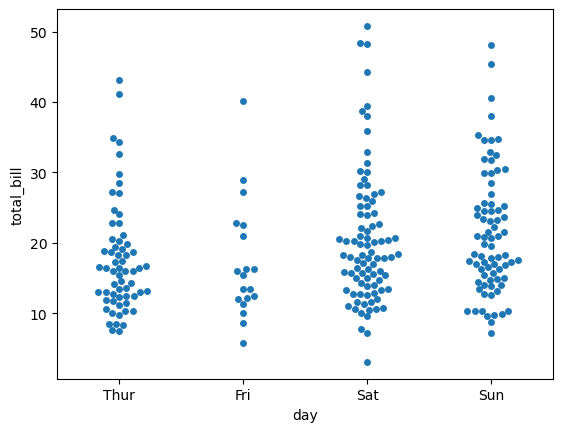

In [ ]:
sns.swarmplot(x="day", y="total_bill", data=tips)
plt.show()
#swarmplot of total bills per day

### Combining Categorical Plots

C:\Users\almok\AppData\Local\Temp\ipykernel_21544\2753510270.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="tip", y="day", data=tips,palette='rainbow')


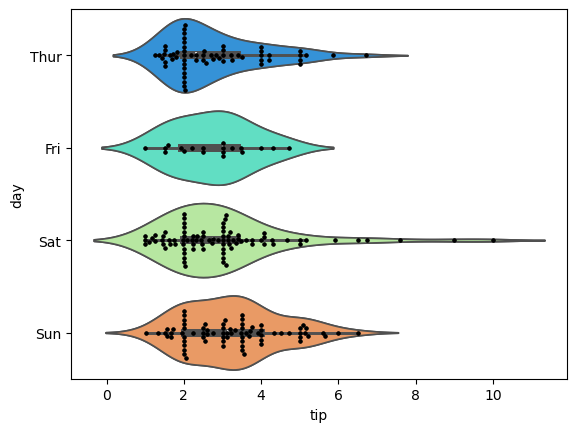

In [ ]:
sns.violinplot(x="tip", y="day", data=tips,palette='rainbow')
sns.swarmplot(x="tip", y="day", data=tips,color='black',size=3)
plt.show()
#swarmplot and violinplot of tip per day overlayed on each other

## catplot

factorplot is the most general form of a categorical plot. It can take in a kind parameter to adjust the plot type:

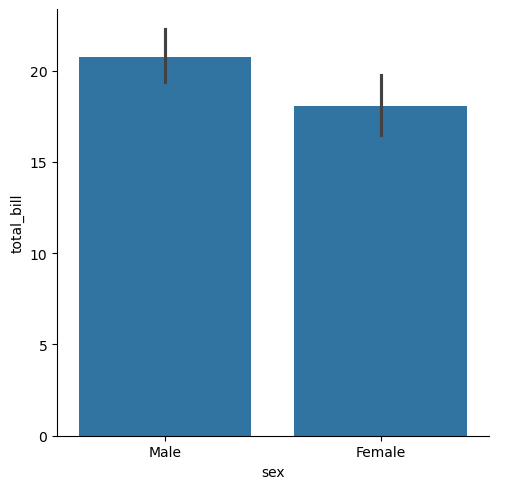

In [ ]:
sns.catplot(x='sex',y='total_bill',data=tips,kind='bar')
plt.show()
#catplot of total bill per male or female

# Matrix Plots

Matrix plots allow you to plot data as color-encoded matrices and can also be used to indicate clusters within the data (later in the machine learning section we will learn how to formally cluster data).

Let's begin by exploring seaborn's heatmap and clutermap:

In [ ]:
import seaborn as sns
%matplotlib inline
#imports

In [ ]:
flights = sns.load_dataset('flights')
#loading the flights dataset

In [ ]:
tips = sns.load_dataset('tips')
#loading the tips dataset

In [ ]:
tips.head()
#showing the tips dataset 

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
flights.head()
#showing the flights dataset

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


## Heatmap

In order for a heatmap to work properly, your data should already be in a matrix form, the sns.heatmap function basically just colors it in for you. For example:

In [ ]:
tips.head()
#showing the tips dataset

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


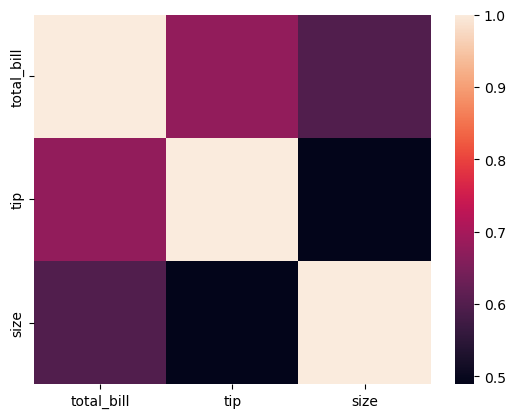

In [276]:
# Matrix form for correlation data
tips.corr(numeric_only=True)
plt.show()

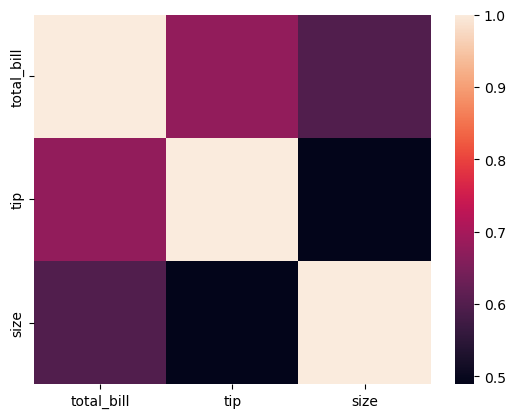

In [ ]:
# Matrix form for correlation data
sns.heatmap(tips.corr(numeric_only=True))
plt.show()

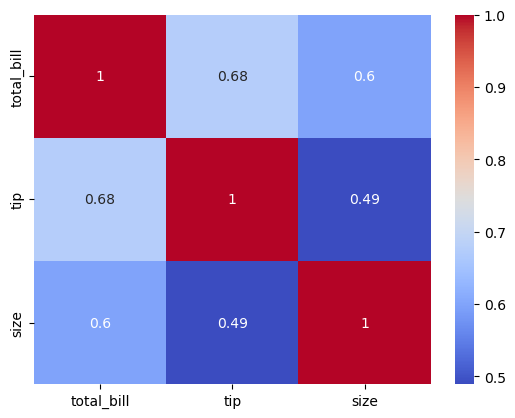

In [ ]:
# Matrix form for correlation data with annotations and coolwarm colors
sns.heatmap(tips.corr(numeric_only=True),cmap='coolwarm',annot=True)
plt.show()

Or for the flights data:

In [ ]:
flights.pivot_table(values='passengers',index='month',columns='year')
#showing a pivot table of passengers per month each year

C:\Users\almok\AppData\Local\Temp\ipykernel_21544\2056291100.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  flights.pivot_table(values='passengers',index='month',columns='year')


year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112.0,115.0,145.0,171.0,196.0,204.0,242.0,284.0,315.0,340.0,360.0,417.0
Feb,118.0,126.0,150.0,180.0,196.0,188.0,233.0,277.0,301.0,318.0,342.0,391.0
Mar,132.0,141.0,178.0,193.0,236.0,235.0,267.0,317.0,356.0,362.0,406.0,419.0
Apr,129.0,135.0,163.0,181.0,235.0,227.0,269.0,313.0,348.0,348.0,396.0,461.0
May,121.0,125.0,172.0,183.0,229.0,234.0,270.0,318.0,355.0,363.0,420.0,472.0
Jun,135.0,149.0,178.0,218.0,243.0,264.0,315.0,374.0,422.0,435.0,472.0,535.0
Jul,148.0,170.0,199.0,230.0,264.0,302.0,364.0,413.0,465.0,491.0,548.0,622.0
Aug,148.0,170.0,199.0,242.0,272.0,293.0,347.0,405.0,467.0,505.0,559.0,606.0
Sep,136.0,158.0,184.0,209.0,237.0,259.0,312.0,355.0,404.0,404.0,463.0,508.0


C:\Users\almok\AppData\Local\Temp\ipykernel_21544\3180738946.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pvflights = flights.pivot_table(values='passengers',index='month',columns='year')


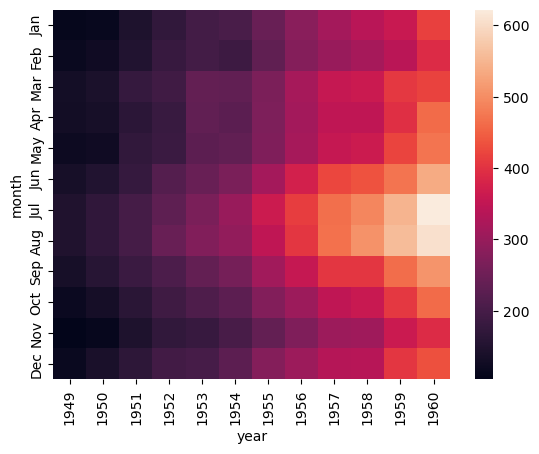

In [ ]:
pvflights = flights.pivot_table(values='passengers',index='month',columns='year')
sns.heatmap(pvflights)
plt.show()
#a heatmap of the previous pivot table

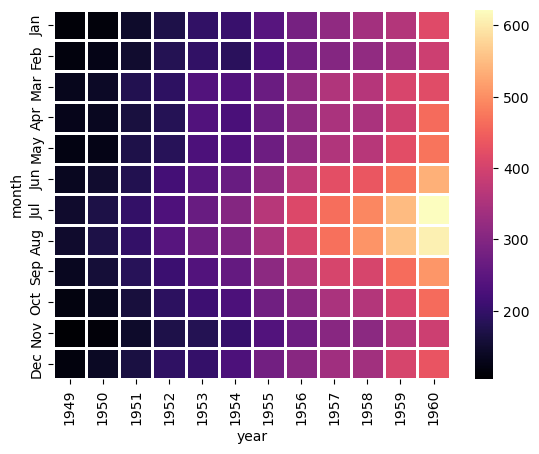

In [ ]:
sns.heatmap(pvflights,cmap='magma',linecolor='white',linewidths=1)
plt.show()
# the same heatmap as before but with a linewidth of 1 

## clustermap

The clustermap uses hierarchal clustering to produce a clustered version of the heatmap. For example:

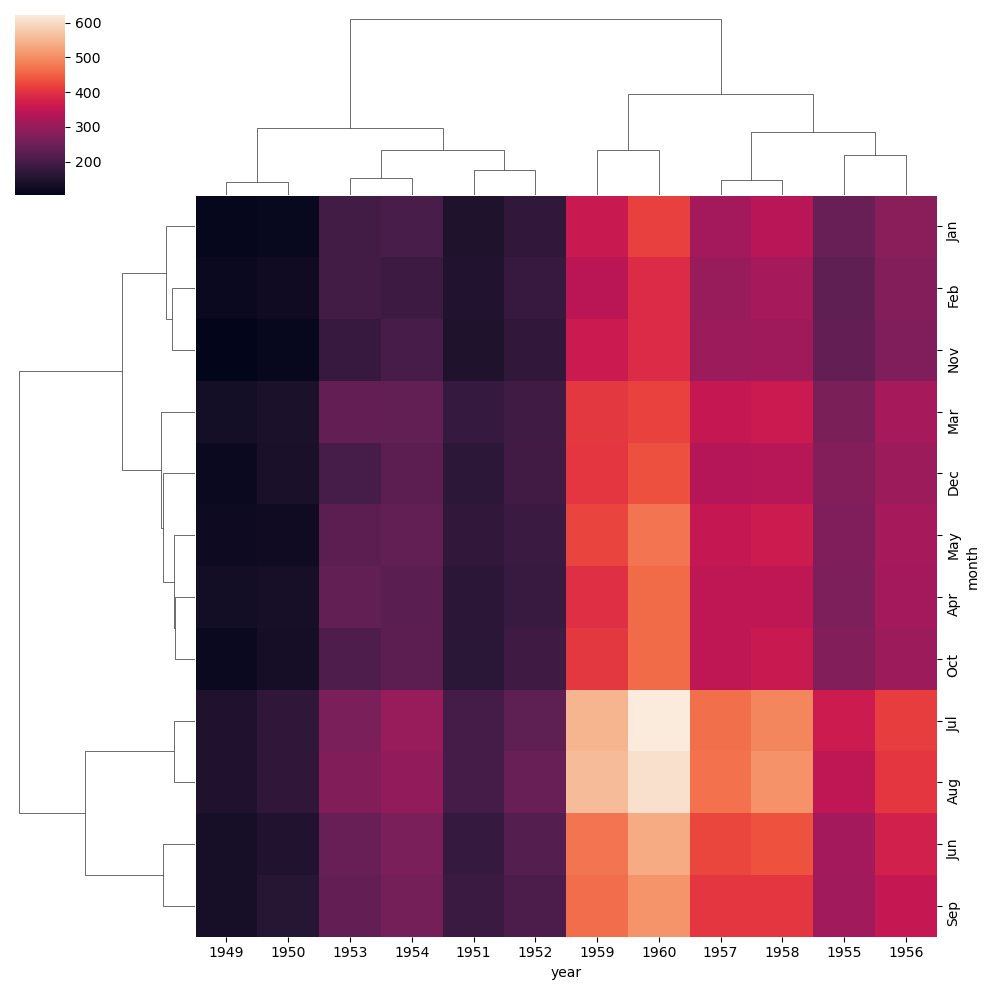

In [ ]:
sns.clustermap(pvflights)

plt.show()
# a clustermeap of the same pivot table

Notice now how the years and months are no longer in order, instead they are grouped by similarity in value (passenger count). That means we can begin to infer things from this plot, such as August and July being similar (makes sense, since they are both summer travel months)

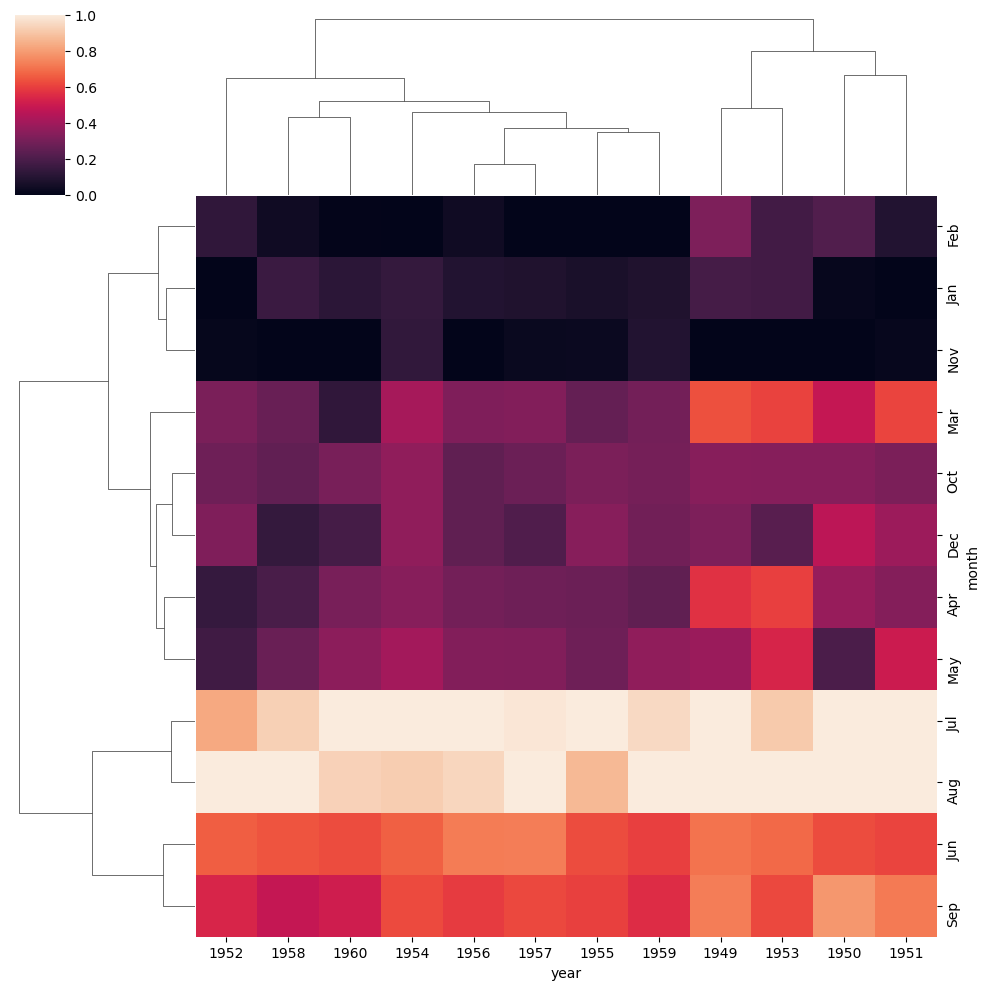

In [ ]:
# More options to get the information a little clearer like normalization
sns.clustermap(pvflights,standard_scale=1)
plt.show()

# Regression Plots

Seaborn has many built-in capabilities for regression plots, however we won't really discuss regression until the machine learning section of the course, so we will only cover the **lmplot()** function for now.

**lmplot** allows you to display linear models, but it also conveniently allows you to split up those plots based off of features, as well as coloring the hue based off of features.

Let's explore how this works:

In [ ]:
import seaborn as sns #imports
%matplotlib inline

In [ ]:
tips = sns.load_dataset('tips')
#loading the tips dataset


In [ ]:
tips.head()
#showing the tips dataset


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## lmplot()

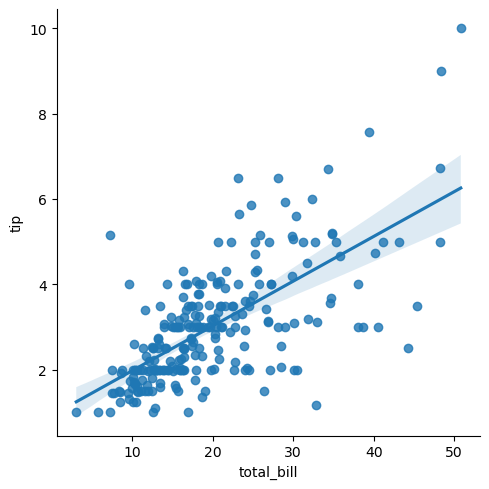

In [ ]:
sns.lmplot(x='total_bill',y='tip',data=tips)
plt.show()
# showing the implot of tips per total bil


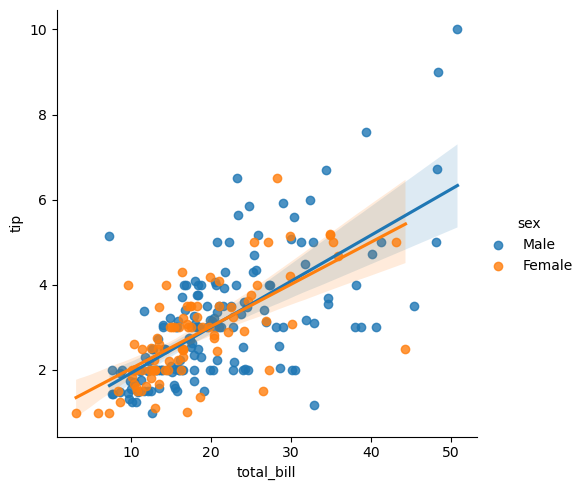

In [ ]:
sns.lmplot(x='total_bill',y='tip',data=tips,hue='sex')
plt.show()
# the same as before but split into male and female

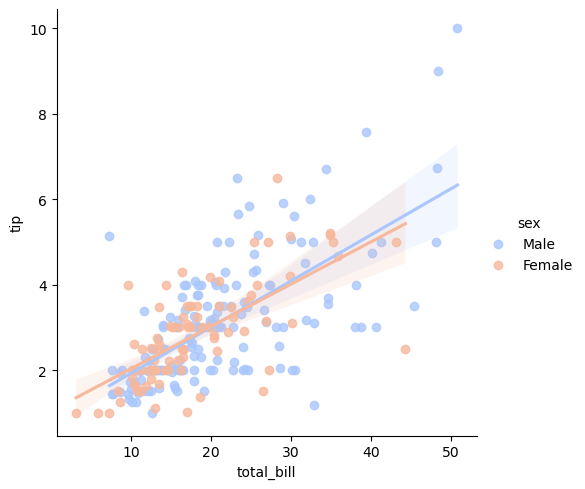

In [ ]:
sns.lmplot(x='total_bill',y='tip',data=tips,hue='sex',palette='coolwarm')
plt.show()
#the same as before but with the coolwarm palette

## Using a Grid

We can add more variable separation through columns and rows with the use of a grid. Just indicate this with the col or row arguments:

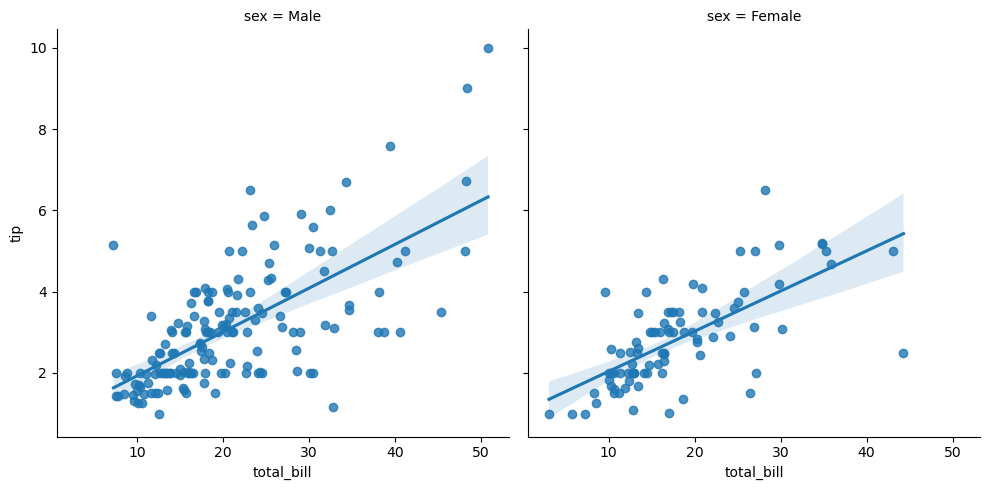

In [ ]:
sns.lmplot(x='total_bill',y='tip',data=tips,col='sex')
plt.show()
#the same implot of male and female are split into a grid

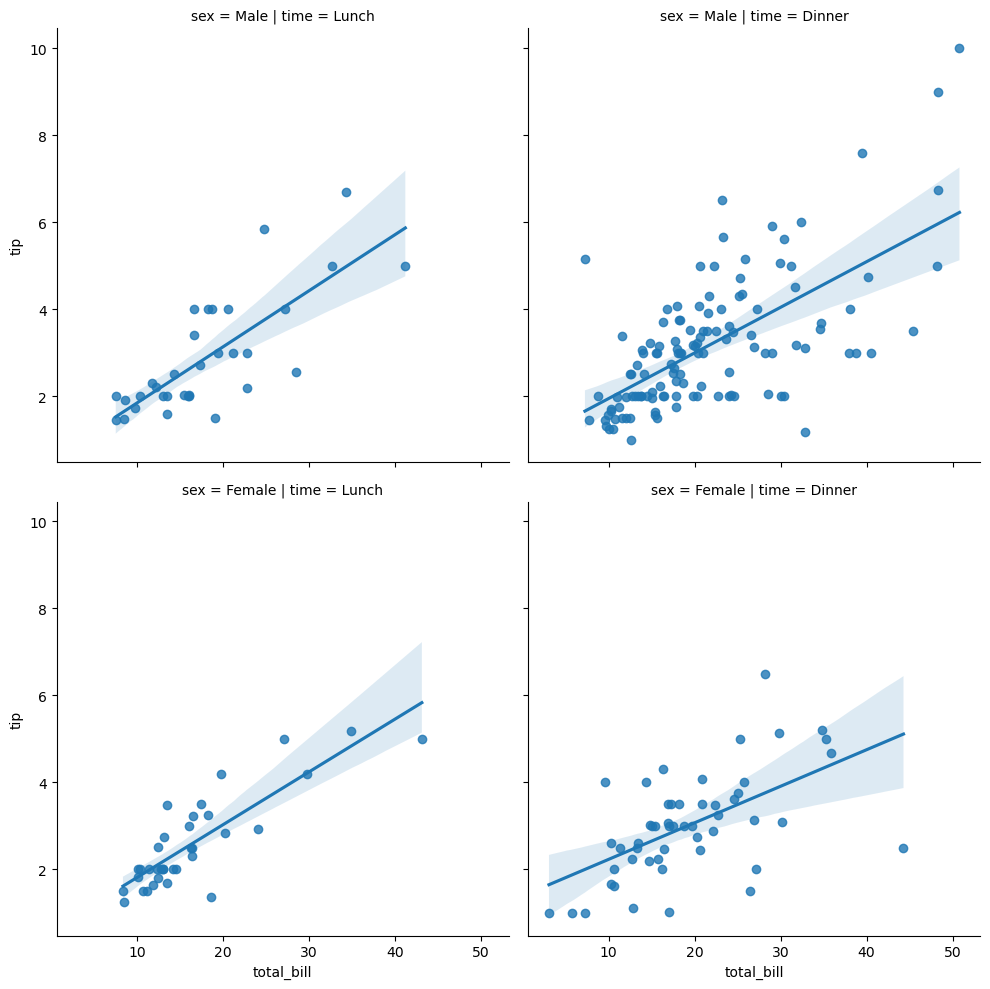

In [ ]:
sns.lmplot(x="total_bill", y="tip", row="sex", col="time",data=tips)
plt.show()
# this time the grid shows splits them based on sex and time

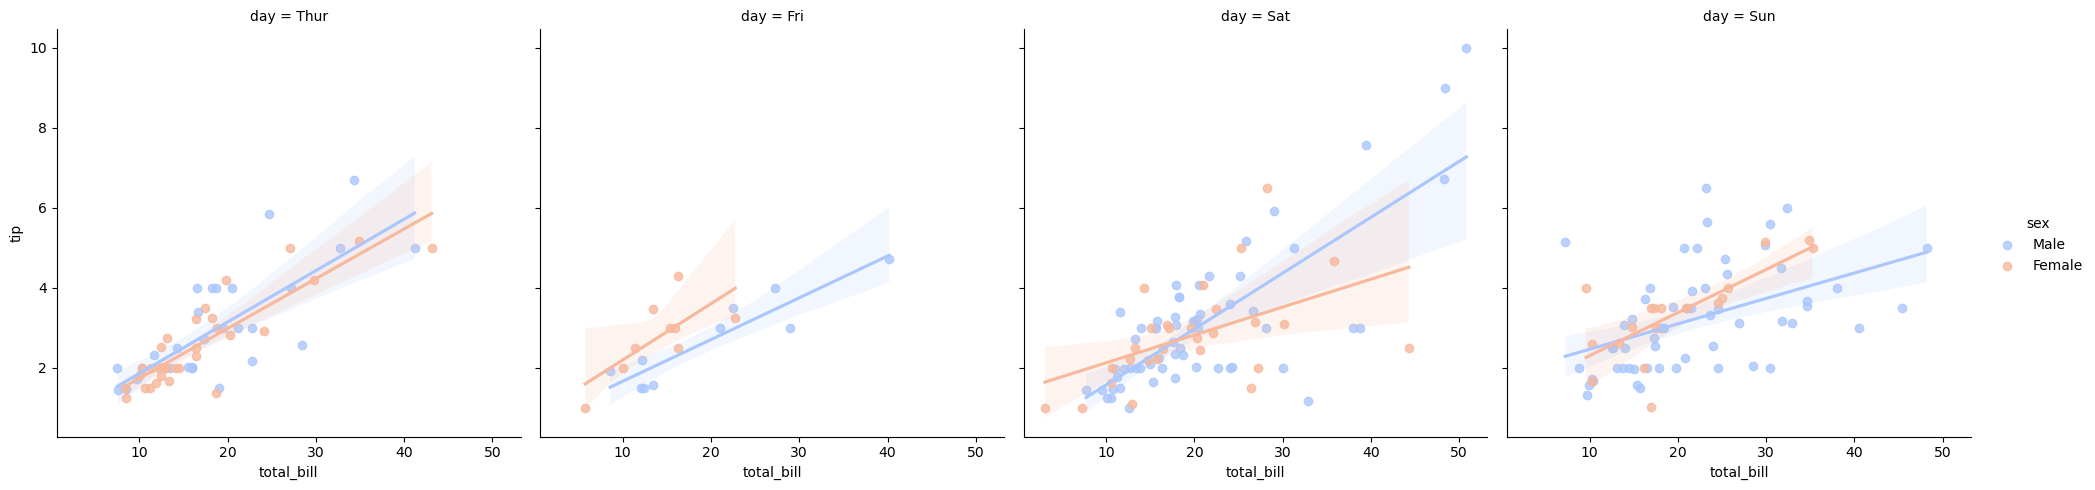

In [ ]:
sns.lmplot(x='total_bill',y='tip',data=tips,col='day',hue='sex',palette='coolwarm')
plt.show()
# split based on day

## Aspect and Size

Seaborn figures can have their size and aspect ratio adjusted with the **height** and **aspect** parameters:

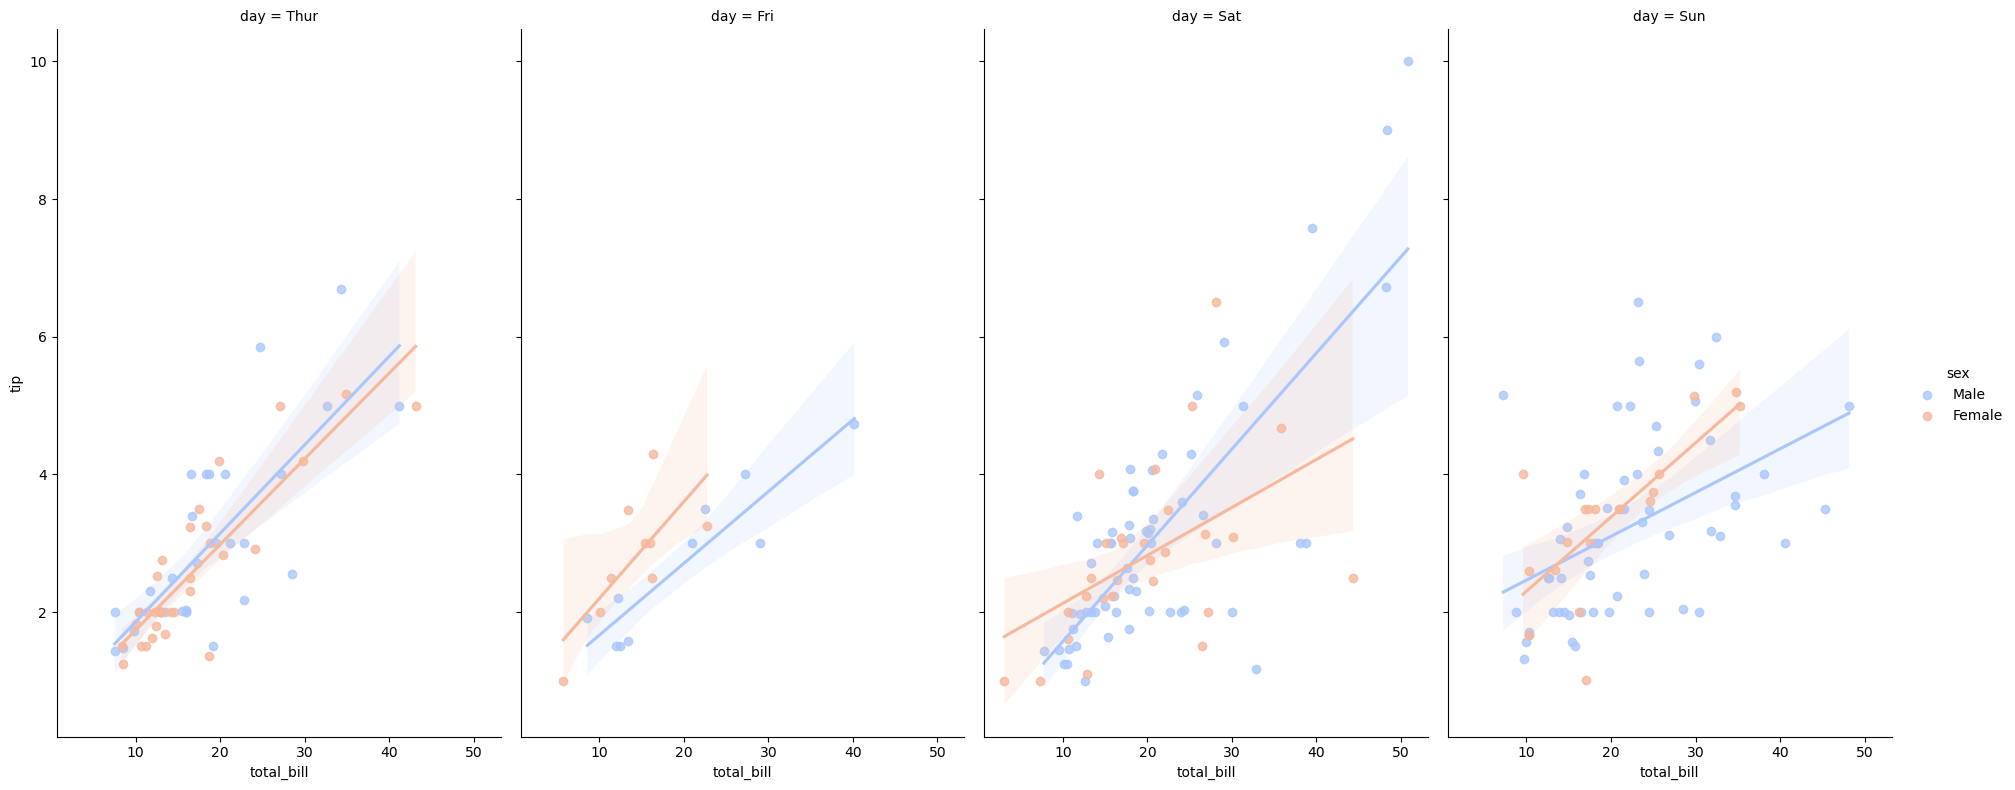

In [ ]:
sns.lmplot(x='total_bill',y='tip',data=tips,col='day',hue='sex',palette='coolwarm',
          aspect=0.6,height=8)

plt.show()
# same but with size changed

### Reference:

* https://seaborn.pydata.org/ - Seaborn: statistical data visualization


* https://seaborn.pydata.org/tutorial/color_palettes.html - Color palettes